# A complete course on Paper 2
### *Representation Dimension Is a Weak, Non-Monotone Lever on Memorisation in Small-Sample Tabular Diffusion*

This notebook rebuilds **every idea in the paper from scratch** — the data handling, the diffusion model, the memorisation metric ρ and its companions, the representations, the calibration baselines, and every statistical method — and tests each one on **synthetic random data where the true answer is known**. The aim is that, by the end, you can explain each number in the paper, say what would make it wrong, and defend it in front of a reviewer.

**How to use it.** Run top to bottom (`Kernel → Restart & Run All`). Everything runs on a CPU in roughly 10–15 minutes; set `FAST = True` in the setup cell for a ~4-minute version with smaller experiments. Each module has the same shape:

1. **Idea** — what the paper does and why.
2. **Mathematics** — the exact definition.
3. **Code** — a minimal implementation you can read in one screen.
4. **Test on synthetic data** — a case where we *know* the right answer, so you can see the method succeed or fail.
5. **What to take away** and **exercises**.

**Map of the paper → this course**

| Paper section | What it does | Module |
|---|---|---|
| §3.1 The measurement | ρ, near-copy fraction, floor, median, minimum over checkpoints, τ-mem | 2, 3, 6 |
| §3.2 Grid | datasets, representations (standard, quantile, autoencoder, PCA, random projection), subsampling, validation split | 1, 4 |
| §3.2 Models | class-conditional DDPM, cosine schedule, ε-prediction, stochastic reverse sampler, clamp | 5 |
| §3.3 Leakage control | deduplication, fit-on-train-only, residual overlap | 1 |
| §3.4 Inference | experimental cells, bootstrap over cells, Spearman saturation, within-cell slope, composition | 9 |
| §4.1 Calibration | reference sampler, fixed-σ copier, log-scale artefact share, Mann–Whitney | 7 |
| §4.2 Claim 1 (sample size) | within-cell Spearman, robustness, censoring, Kaplan–Meier | 6, 9 |
| §4.3 Claim 2 (dimension) | slope per ten dimensions, partial R², U-shape, bootstrap ratio, dimension copier, clamp confound | 4, 8, 9 |
| §4.4 Claim 3 (width) | width sweep, fidelity (precision, energy distance), underfitting | 10 |
| §4.5 Claim 4 (augmentation) | ΔAUC, clustered intervals, Cohen's d, composition, ratio confound | 11 |
| §4.6 Excluded runs | near-degenerate directions, ratio divergence, scale-free exclusion | 4 |
| Throughout | effect size vs significance, bounded null, equivalence, multiplicity, Simpson's paradox | 9 |
| Synthesis | the four claims, the evidence for each, and what a reviewer can attack | 12 |

## Module 0 — Setup

We use NumPy/SciPy for geometry and statistics, scikit-learn for representations and classifiers, statsmodels for regression, and PyTorch for the diffusion model. Nothing here needs a GPU.

`FAST = True` shrinks every training experiment (fewer steps, seeds and sample sizes). The *lessons* are identical; the curves are noisier.

In [1]:
FAST = False          # True -> ~4 min total, smaller experiments

import math, time, warnings, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import torch

warnings.filterwarnings('ignore')
torch.set_num_threads(4)
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.spines.top': False,
                     'axes.spines.right': False, 'legend.frameon': False})
COL = ['#2166AC', '#B85042', '#1B7837', '#762A83', '#E08214', '#7F7F7F']
T0 = time.time()
print('torch', torch.__version__, '| numpy', np.__version__)

torch 2.14.1+cu130 | numpy 2.4.6


---
## Module 1 — The data, the split, and leakage control

### Idea
The paper uses small clinical tables. We replace them with **synthetic tables whose generating process we control**, so we always know the truth. Each table has:

* a **low intrinsic dimension** *m* (real tabular data lives near a low-dimensional manifold) embedded non-linearly in *D* observed columns;
* a **binary class label** with imbalance (as in the clinical tables);
* optionally, **rare near-constant columns** (like the rare binary health indicators in CDC diabetes) — these matter in Module 4.

### The split (paper §3.2–3.3)
1. **Deduplicate** on (features + label) *before* any split, so a record cannot sit in both training and held-out sets.
2. Fix a **held-out set H** once. It is never touched by any fitted component.
3. From the remaining pool, draw a **subsample of size n** (the variable the paper sweeps).
4. Carve a **25 % validation split** from the subsample for checkpoint selection (n ≥ 50 only), so the model trains on **0.75 n** rows. *n is the subsample size, not the number of rows the model sees* — a labelling detail the paper states explicitly.
5. Every representation is **fitted on the training rows only**.

In [2]:
def make_table(N, D=8, m=3, sep=1.6, minority=0.3, n_rare=0, rare_p=0.02, seed=0):
    '''Synthetic tabular data: m-dim latent manifold, nonlinear embedding in D columns, binary label.
    n_rare adds near-constant columns: almost always 0, occasionally 1, plus 1e-6 jitter.'''
    g = np.random.default_rng(seed)                  # fixes the *dataset* (its geometry)
    A = g.normal(size=(m, D)) / np.sqrt(m)
    mu = g.normal(size=m); mu = sep * mu / np.linalg.norm(mu)
    b = g.normal(size=D)
    r = np.random.default_rng(seed + 10_000)          # draws the *records*
    y = (r.random(N) < minority).astype(int)
    z = r.normal(size=(N, m)) + y[:, None] * mu
    X = 1.5 * np.tanh(z @ A + 0.3 * b) + 0.4 * (z @ A) + 0.08 * r.normal(size=(N, D))
    if n_rare:
        R = (r.random((N, n_rare)) < rare_p).astype(float) + 1e-6 * r.normal(size=(N, n_rare))
        X = np.hstack([X, R])
    return X, y

def dedup(X, y):
    _, idx = np.unique(np.round(np.c_[X, y], 10), axis=0, return_index=True)
    idx = np.sort(idx); return X[idx], y[idx]

class Dataset:
    '''Pool + fixed held-out set + reproducible subsamples, mirroring the paper's protocol.'''
    def __init__(self, name, N=6000, n_hold=1000, **kw):
        X, y = dedup(*make_table(N, **kw))
        g = np.random.default_rng(1)
        p = g.permutation(len(X))
        self.name = name
        self.H, self.yH = X[p[:n_hold]], y[p[:n_hold]]          # held-out, fixed once
        self.P, self.yP = X[p[n_hold:]], y[p[n_hold:]]          # pool for subsampling
        self.D = X.shape[1]
    def subsample(self, n, seed):
        g = np.random.default_rng(1000 + seed)
        idx = g.choice(len(self.P), n, replace=False)
        X, y = self.P[idx], self.yP[idx]
        if n < 50:                                              # paper: no validation split below 50
            return X, y, None, None
        k = int(round(0.75 * n))
        return X[:k], y[:k], X[k:], y[k:]                       # train (0.75n), validation (0.25n)

DS_A = Dataset('A', D=8, m=3, seed=1)
DS_B = Dataset('B', D=8, m=5, sep=1.2, minority=0.2, seed=2)
for ds in (DS_A, DS_B):
    Xt, yt, Xv, yv = ds.subsample(120, seed=0)
    print(f'dataset {ds.name}: pool {ds.P.shape}, held-out {ds.H.shape}, '
          f'n=120 -> train {Xt.shape[0]} rows, val {Xv.shape[0]} rows, minority {ds.yP.mean():.2f}')

# leakage check the paper describes: does any held-out row appear in a training subsample?
Xt, *_ = DS_A.subsample(800, 0)
overlap = (cdist(DS_A.H, Xt).min(1) < 1e-9).sum()
print('held-out rows duplicated in this training subsample:', overlap)

dataset A: pool (5000, 8), held-out (1000, 8), n=120 -> train 90 rows, val 30 rows, minority 0.30
dataset B: pool (5000, 8), held-out (1000, 8), n=120 -> train 90 rows, val 30 rows, minority 0.21
held-out rows duplicated in this training subsample: 0


**Take-away.** Dedup-before-split and fit-on-train-only are *structural* leakage controls. The paper is honest that its "shuffled-label" self-test had no power (it ran on random features with random labels, so chance performance was guaranteed whether or not the pipeline leaked) — the real defence is the structure above plus the **residual-overlap analysis**: re-run the headline statistic on runs with zero held-out duplicates and check it does not move (+0.937 → +0.928 in the paper).

*Exercise 1.1.* Remove the `dedup` call, duplicate 5 % of the rows deliberately, and count how many held-out rows now appear in training subsamples at n = 800.

---
## Module 2 — Nearest-neighbour geometry: the ground ρ stands on

### Idea
Everything in the paper is built from one primitive: the **nearest-neighbour (NN) distance** from a point *a* to a set *B*,
$$ d(a, B) = \min_{b\in B}\lVert a-b\rVert_2 . $$
Two facts about it drive half of the paper's subtleties:

1. **NN spacing shrinks as the training set grows.** For points with intrinsic dimension *m*, the typical NN distance scales like $n^{-1/m}$. So any "how close is synthetic data to training data" statistic will change with *n* **even if the generator's behaviour does not** — this is why the paper needs a calibration (Module 7).
2. **Distances concentrate as dimension grows.** In high dimension, the nearest and farthest neighbours become relatively similar, so ratios of distances drift with dimension — this is why the paper checks whether ρ is "dimension-dependent by construction" (Module 8).

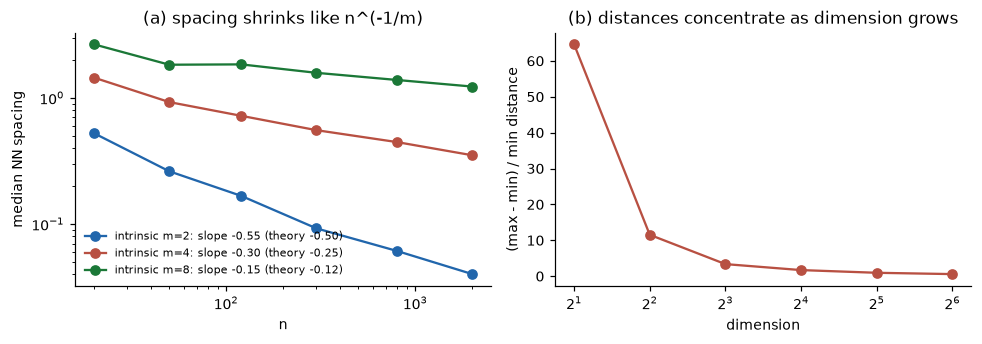

In [3]:
def nn_dist(A, B, exclude_self=False):
    '''Distance from each row of A to its nearest neighbour in B (self excluded if A is B).'''
    tree = cKDTree(B)
    d, _ = tree.query(A, k=2 if exclude_self else 1)
    return d[:, 1] if exclude_self else d

ns = [20, 50, 120, 300, 800, 2000]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
for m, c in zip([2, 4, 8], COL):
    sp = []
    for n in ns:
        X = np.random.default_rng(n).normal(size=(n, m))
        sp.append(np.median(nn_dist(X, X, exclude_self=True)))
    slope = np.polyfit(np.log(ns), np.log(sp), 1)[0]
    ax[0].loglog(ns, sp, 'o-', color=c, label=f'intrinsic m={m}: slope {slope:.2f} (theory {-1/m:.2f})')
ax[0].set_xlabel('n'); ax[0].set_ylabel('median NN spacing'); ax[0].legend(fontsize=7)
ax[0].set_title('(a) spacing shrinks like n^(-1/m)')

dims = [2, 4, 8, 16, 32, 64]
contrast = []
for d in dims:
    X = np.random.default_rng(d).normal(size=(500, d))
    D_ = cdist(X[:50], X); D_[D_ == 0] = np.nan
    contrast.append(np.nanmean((np.nanmax(D_, 1) - np.nanmin(D_, 1)) / np.nanmin(D_, 1)))
ax[1].semilogx(dims, contrast, 'o-', color=COL[1], base=2)
ax[1].set_xlabel('dimension'); ax[1].set_ylabel('(max - min) / min distance')
ax[1].set_title('(b) distances concentrate as dimension grows')
plt.tight_layout(); plt.show()

**Take-away.** Panel (a) is the reason the paper's denominator shrinks with *n*; panel (b) is the reason a ratio of NN distances is not automatically comparable across dimension. Both are properties of geometry, not of any model.

*Exercise 2.1.* Generate data on a 2-D plane embedded in 20 dimensions (`X = Z @ A` with `Z` 2-D). Which slope do you see — −1/2 or −1/20? Why does this matter for real tables?

---
## Module 3 — The memorisation metric ρ and its companions

### Definition (paper §3.1)
Let $T$ be the training rows, $H$ the held-out rows, $S$ the synthetic samples, all standardised by the training mean and SD and expressed in the space the model generates in. Then
$$
\rho \;=\; \frac{\operatorname{median}_{s\in S}\, d(s, T)}{\max\!\Big(\operatorname{median}_{h\in H}\, d(h, T),\;\; 0.25\cdot\operatorname{median}_{t\in T}\, d(t, T\setminus\{t\})\Big)}.
$$

* **Numerator:** how close synthetic samples sit to their nearest training record.
* **Denominator:** how close *genuinely unseen real records* sit to their nearest training record — the natural spacing of the distribution at this *n*.
* **Floor:** guards against a chance coincidence making the denominator ≈ 0. (The paper shows it never binds.)
* **Median, not mean:** a handful of off-scale samples would dominate a mean.

**Reading it.** ρ ≪ 1: synthetic samples hug training records more tightly than real unseen data does → copying. ρ ≈ 1: they sit where fresh real data would. ρ > 1: they sit *further* out — which can mean a poor, scattered generator, not a safe one.

### Companions
* **Near-copy fraction:** share of synthetic samples within half the median train-to-train spacing of a training record (opposite sign convention: higher = more copying).
* **Authenticity** (Alaa et al. 2022): a synthetic sample is *unauthentic* if it is closer to its nearest training record $t$ than $t$ is to its own nearest training neighbour; authenticity = fraction authentic.
* **Precision / recall on k-NN manifolds** (Kynkäänniemi et al. 2019): precision = share of synthetic samples inside the k-NN ball of some real point (fidelity); recall = share of real points inside the k-NN ball of some synthetic point (coverage).
* **Energy distance** (Székely & Rizzo): a distributional distance, $\mathcal E = 2\,\mathbb E\lVert X-Y\rVert - \mathbb E\lVert X-X'\rVert - \mathbb E\lVert Y-Y'\rVert$. Note it is **near zero for a perfect copier** — exactly why the paper does *not* use it to measure memorisation.

In [4]:
def standardise_by(T, *others):
    mu, sd = T.mean(0), T.std(0)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return [(A - mu) / sd for A in (T, *others)]

def rho_stats(S, T, H, floor=0.25, standardise=True):
    if standardise:
        T, S, H = standardise_by(T, S, H)
    dS, dH = nn_dist(S, T), nn_dist(H, T)
    dT = nn_dist(T, T, exclude_self=True)
    num, den_raw, sp = np.median(dS), np.median(dH), np.median(dT)
    den = max(den_raw, floor * sp, 1e-9)
    return dict(rho=num / den, num=num, den=den_raw, spacing=sp,
                floor_binds=bool(den_raw < floor * sp),
                near_copy=float(np.mean(dS < 0.5 * sp)),
                rho_mean=np.mean(dS) / max(np.mean(dH), 1e-9),
                max_nn=float(dS.max()))

def authenticity(S, T):
    tree = cKDTree(T); dS, j = tree.query(S, k=1)
    dT = nn_dist(T, T, exclude_self=True)
    return float(np.mean(dS >= dT[j]))

def precision_recall(R, S, k=5):
    rR = np.sort(cdist(R, R), 1)[:, k]          # k-NN radius of each real point
    rS = np.sort(cdist(S, S), 1)[:, k]
    prec = np.mean((cdist(S, R) <= rR[None, :]).any(1))
    rec  = np.mean((cdist(R, S) <= rS[None, :]).any(1))
    return float(prec), float(rec)

def energy_distance(X, Y, unbiased=True):
    n, m = len(X), len(Y)
    dxy = cdist(X, Y).mean()
    dxx, dyy = cdist(X, X), cdist(Y, Y)
    exx = dxx.sum() / (n * (n - 1)) if unbiased else dxx.mean()
    eyy = dyy.sum() / (m * (m - 1)) if unbiased else dyy.mean()
    return 2 * dxy - exx - eyy

### Test 3.1 — five generators with known behaviour
We know exactly what each of these does, so we can check that ρ reads them correctly:

| generator | what it really does | ρ should be |
|---|---|---|
| reference sampler | fresh draws from the true distribution | ≈ 1 |
| exact copier | returns training rows | 0 |
| noisy copier | training rows + small Gaussian noise | between 0 and 1, rising with noise |
| Gaussian fit (inflated) | a broad Gaussian matched to T's mean/cov ×1.5 | > 1 (scatters) |
| centroid collapse | all samples at the two class means | **≈ 1 although the generator is useless** |

The last line is the important one: ρ measures *proximity to training records*, not copying per se. That is why the paper pairs it with the near-copy fraction and authenticity, and says ρ ≈ 1 is "a desirable condition under this metric, not a demonstration of faithful sampling".

In [5]:
ds = DS_A
T, yT, _, _ = ds.subsample(300, seed=0)
H = ds.H
g = np.random.default_rng(0)
fresh, _ = make_table(4000, D=8, m=3, seed=1); fresh = fresh[-1000:]       # same generator, new records
mean, cov = T.mean(0), np.cov(T.T)
cent = np.vstack([np.repeat(T[yT == k].mean(0, keepdims=True), 500, 0) for k in (0, 1)])
gens = {
    'reference sampler':   fresh,
    'exact copier':        T[g.integers(0, len(T), 1000)],
    'noisy copier σ=0.1':  T[g.integers(0, len(T), 1000)] + 0.1 * T.std(0) * g.normal(size=(1000, 8)),
    'noisy copier σ=0.3':  T[g.integers(0, len(T), 1000)] + 0.3 * T.std(0) * g.normal(size=(1000, 8)),
    'Gaussian fit ×1.5':   g.multivariate_normal(mean, 1.5 * cov, 1000),
    'centroid collapse':   cent + 1e-3 * g.normal(size=cent.shape),
}
rows = []
Ts, Hs = standardise_by(T, H)
for name, S in gens.items():
    r = rho_stats(S, T, H)
    Ss = standardise_by(T, S)[1]
    p, rc = precision_recall(Hs[:500], Ss[:500])
    rows.append(dict(generator=name, rho=r['rho'], near_copy=r['near_copy'],
                     authenticity=authenticity(Ss, Ts), precision=p, recall=rc,
                     energy_to_heldout=energy_distance(Ss[:500], Hs[:500])))
pd.DataFrame(rows).set_index('generator').round(3)

,rho,near_copy,authenticity,precision,recall,energy_to_heldout
generator,,,,,,
reference sampler,0.977,0.021,0.465,0.986,0.986,-0.002
exact copier,0.000,1.000,0.000,0.996,0.820,0.014
noisy copier σ=0.1,0.429,0.693,0.022,0.982,0.894,0.007
noisy copier σ=0.3,1.190,0.003,0.662,0.696,0.974,0.032
Gaussian fit ×1.5,1.348,0.005,0.725,0.806,0.994,0.039
centroid collapse,1.026,0.000,0.500,1.000,0.000,1.789


**Read the table carefully.**
* The **reference sampler** scores ρ ≈ 1 by construction (the paper: "it anchors the scale … and validates nothing beyond that").
* The **exact copier** has ρ = 0, near-copy = 1, authenticity = 0 — and a *small* energy distance, which is why energy distance cannot measure memorisation.
* The **centroid collapse** scores ρ ≈ 1 — the "ideal" value — while being a useless generator: recall ≈ 0 and a huge energy distance. **ρ ≈ 1 is necessary-looking but not sufficient**; this is exactly why the paper says ρ ≈ 1 is "a desirable condition under this metric, not a demonstration of faithful sampling".
* The **noisy copier at σ = 0.3** already has ρ > 1: noise with per-coordinate scale σ has norm ≈ σ√D, so a "copier" can sit farther from training data than fresh data does. Remember this for Module 7.
* The **unbiased energy distance** can be slightly negative for the reference sampler — it estimates a quantity that is exactly 0, and its sampling noise goes both ways.
* The **inflated Gaussian** has ρ > 1 and lower precision: a bad generator looks "safe" on ρ. This is exactly the paper's width-64 caveat (Module 10).

### Test 3.2 — median vs mean, and the floor

In [6]:
S = gens['noisy copier σ=0.1'].copy()
r0 = rho_stats(S, T, H)
S[:3] = 1e4                      # three off-scale samples, like the paper's 3 runs at n = 20
r1 = rho_stats(S, T, H)
print(f"median-based rho: {r0['rho']:.3f} -> {r1['rho']:.3f}   (unchanged)")
print(f"mean-based   rho: {r0['rho_mean']:.3f} -> {r1['rho_mean']:.1f}   (destroyed by 3 of 1000 samples)")
print(f"floor binds? {r0['floor_binds']}  (denominator {r0['den']:.3f} vs 0.25 x spacing {0.25*r0['spacing']:.3f})")

# when WOULD the floor bind? if most held-out rows were duplicates of training rows:
Hdup = np.vstack([T[:900], H[:100]])
print('with 90% held-out duplicates, floor binds:', rho_stats(gens['noisy copier σ=0.1'], T, Hdup)['floor_binds'])

median-based rho: 0.429 -> 0.430   (unchanged)
mean-based   rho: 0.405 -> 152.6   (destroyed by 3 of 1000 samples)
floor binds? False  (denominator 0.628 vs 0.25 x spacing 0.155)
with 90% held-out duplicates, floor binds: True


**Take-away.** The median is robust to a few extreme samples; the floor is a safety constant that only matters if held-out data coincides with training data — the paper verified it never binds, which is why it calls it "an inert constant rather than a sensitivity analysis".

*Exercise 3.1.* Sweep the noisy copier's σ from 0 to 1.5 and plot ρ, near-copy fraction and authenticity against σ. At what σ does ρ cross 1? Is that the same σ at which near-copy fraction hits 0?

---
## Module 4 — Representations, the clamp, reconstruction residual, and off-scale failures

### Idea
The paper's question is whether the **space the model generates in** — and specifically its **dimension** — changes memorisation. Five families:

| family | map | fitted to data? | dimension |
|---|---|---|---|
| standard | z-score each column | yes (mean, SD) | D |
| quantile | each marginal → standard normal via its empirical CDF | yes | D |
| autoencoder | learned non-linear encoder/decoder, 8-d latent | yes | 8 |
| PCA | standardise, project on top-d principal axes | **yes** (axes follow the covariance) | d |
| random projection | standardise, project on a random orthonormal basis, scale by √(D/d) | **no** (data-independent) | d |

The **PCA vs random projection** contrast is the design's pivot: both are linear projections of the same standardised data, but only PCA is fitted. Any difference is "fitting + variance alignment together", as the paper carefully says.

### Random projection mathematics
Draw $G\in\mathbb R^{D\times d}$ with i.i.d. $N(0,1)$ entries, orthonormalise by QR to get $Q$ ($Q^\top Q = I_d$), then map $z = \sqrt{D/d}\; Q^\top x$. For standardised $x$, each coordinate has variance $\tfrac{D}{d}\,q^\top\Sigma q \approx \tfrac{D}{d}$, so **coordinate SD ≈ √(D/d)** — 2.29 at D = 21, d = 4, exactly the paper's number. The √(D/d) factor (Johnson–Lindenstrauss scaling) preserves *mean pairwise distances*; without it, projection would shrink all distances and "manufacture" a dimension effect. But it does **not** preserve *nearest-neighbour* distances, which is what ρ uses.

In [7]:
class Rep:
    '''fit on training rows only; transform; inverse back to feature space.'''
    def __init__(self, kind, d=None, seed=0):
        self.kind, self.d, self.seed = kind, d, seed
    def fit(self, X):
        D = X.shape[1]; self.D = D
        self.sc = StandardScaler().fit(X)
        Z = self.sc.transform(X)
        if self.kind == 'quantile':
            self.q = QuantileTransformer(output_distribution='normal',
                                         n_quantiles=min(1000, len(X))).fit(X)
        elif self.kind == 'pca':
            self.p = PCA(min(self.d, D, len(X))).fit(Z)
        elif self.kind == 'randproj':
            G = np.random.default_rng(self.seed).normal(size=(D, self.d))
            self.Q, _ = np.linalg.qr(G)                     # D x d, orthonormal columns
            self.s = np.sqrt(D / self.d)
        return self
    def transform(self, X):
        Z = self.sc.transform(X)
        if self.kind == 'standard': return Z
        if self.kind == 'quantile': return self.q.transform(X)
        if self.kind == 'pca':      return self.p.transform(Z)
        if self.kind == 'randproj': return self.s * Z @ self.Q
    def inverse(self, Zr):
        if self.kind == 'standard': return self.sc.inverse_transform(Zr)
        if self.kind == 'quantile': return self.q.inverse_transform(Zr)
        if self.kind == 'pca':      return self.sc.inverse_transform(self.p.inverse_transform(Zr))
        if self.kind == 'randproj': return self.sc.inverse_transform((Zr / self.s) @ self.Q.T)

# JL check: mean pairwise distance preserved, NN distance not
X21, _ = make_table(800, D=21, m=6, seed=7)
Z = StandardScaler().fit_transform(X21)
print(' d   mean-pairwise ratio   median-NN ratio   coordinate SD   clamp share |z|>5')
for d in [4, 8, 12, 16, 21]:
    rp = Rep('randproj', d, seed=3).fit(X21); Zd = rp.transform(X21)
    mp = cdist(Zd[:300], Zd[:300]).mean() / cdist(Z[:300], Z[:300]).mean()
    nr = np.median(nn_dist(Zd, Zd, True)) / np.median(nn_dist(Z, Z, True))
    print(f'{d:2d}        {mp:.3f}               {nr:.3f}            {Zd.std():.2f}            {np.mean(np.abs(Zd) > 5):.4f}')

 d   mean-pairwise ratio   median-NN ratio   coordinate SD   clamp share |z|>5
 4        1.006               0.524            2.41            0.0497
 8        0.910               0.734            1.52            0.0011
12        0.980               0.911            1.31            0.0004
16        0.983               0.971            1.13            0.0001
21        1.000               1.000            1.00            0.0000


**What you just saw.**
* Mean pairwise distance is preserved (ratio ≈ 1) at every d — the paper's "0.977–1.004" check.
* Median NN distance is *not* preserved: low-d projections squash points together.
* Coordinate SD rises as d falls (≈ √(D/d)), so a sampler that **clamps predicted samples to [−5, 5]** cuts off more coordinates at low d **for random projection only** (PCA coordinates do not get this inflation). That is the paper's **clamp confound**: a purely mechanical reason the random-projection ρ could change with d. The paper flags it as untested — Module 8 lets you test it.

### Test 4.1 — why ρ is computed in representation space
If we generated in a d-dimensional PCA space but measured ρ *after* inverting to feature space, synthetic samples would lie on a d-dimensional subspace while T and H stay full-rank. The numerator would then contain the **reconstruction residual** — a pure dimension artefact. To isolate it we use an **exact copier in representation space**: in that space its ρ is exactly 0 at every d, so anything feature-space ρ shows is the residual alone.

In [8]:
T21, _ = make_table(400, D=21, m=6, seed=7)
H21, _ = make_table(1400, D=21, m=6, seed=7); H21 = H21[400:]
print(' d  residual(median)  rho in rep space  rho in feature space   (generator = exact copier IN rep space)')
for d in [4, 8, 12, 16, 21]:
    rep = Rep('pca', d).fit(T21)
    Zt = rep.transform(T21)
    S_rep = Zt[np.random.default_rng(0).integers(0, len(Zt), 800)]
    resid = np.median(np.linalg.norm(StandardScaler().fit(T21).transform(T21) -
                                     rep.p.inverse_transform(Zt), axis=1))
    r_rep = rho_stats(S_rep, Zt, rep.transform(H21))['rho']
    r_feat = rho_stats(rep.inverse(S_rep), T21, H21)['rho']
    print(f'{d:2d}      {resid:6.2f}           {r_rep:6.3f}             {r_feat:6.3f}')

 d  residual(median)  rho in rep space  rho in feature space   (generator = exact copier IN rep space)
 4        1.80            0.000              0.753
 8        0.53            0.000              0.269
12        0.39            0.000              0.196


16        0.25            0.000              0.127


21        0.00            0.000              0.000


The generator is a perfect copier at every d, yet in feature space it looks less and less like one as d falls — the residual "manufactures a dimension effect on its own", as the paper says. Measuring in representation space avoids it.

### Test 4.2 — off-scale failures and why the paper excludes on a scale-free rule
The paper excluded 26 runs with ρ ≥ 100 and found 8 more with NN distances ~10⁷ that **kept a normal-looking ρ** because numerator and denominator diverged together. All failures happened at **full or near-full dimension** — never after reduction. The likely cause is a near-degenerate direction (a near-constant column) that standardisation blows up and that any reduction discards. We can reproduce the whole story:

In [9]:
# A near-degenerate direction: one column is (almost) constant in the small training subsample
# (SD 1e-6), but the population, and any imperfect generator, deviate from it slightly.
g = np.random.default_rng(11)
X8, _ = make_table(3000, D=8, m=3, seed=11)
T8, H8 = X8[:20], X8[1000:]
def with_col(A, sd): return np.c_[A, sd * g.normal(size=len(A))]
T9 = with_col(T8, 1e-6)                       # training rows: column ~ constant
H9 = with_col(H8, 1e-3)                       # held-out rows: tiny real variation, 1000x the training SD
copy = T8[g.integers(0, 20, 500)] + 0.05 * T8.std(0) * g.normal(size=(500, 8))
cases = {'healthy (column dropped)':                      (copy, T8, H8),
         'generator exact in that column (err 1e-6)':     (with_col(copy, 1e-6), T9, H9),
         'generator slightly off (err 1e-4)':             (with_col(copy, 1e-4), T9, H9),
         'generator off like real data (err 1e-3)':       (with_col(copy, 1e-3), T9, H9)}
rows = []
for name, (S_, T_, H_) in cases.items():
    r = rho_stats(S_, T_, H_)
    rows.append(dict(case=name, rho=r['rho'], numerator=r['num'], denominator=r['den'],
                     passes_rho_filter=r['rho'] < 100, den_over_spacing=r['den'] / r['spacing']))
print(pd.DataFrame(rows).round(3).to_string(index=False))

                                     case   rho  numerator  denominator  passes_rho_filter  den_over_spacing
                 healthy (column dropped) 0.111      0.136        1.226               True             0.784
generator exact in that column (err 1e-6) 0.001      1.064      849.453               True           442.863
        generator slightly off (err 1e-4) 0.096     81.578      849.453               True           442.863
  generator off like real data (err 1e-3) 1.104    937.442      849.453               True           442.863


**What happened.** Standardising by the training SD (10⁻⁶) multiplies any deviation in that column by 10⁶. The held-out rows deviate by ~10⁻³, so the **denominator** explodes to ~10³. What ρ then shows depends only on how the *generator* behaves in a column nobody cares about:
* exact in that column → numerator stays small → ρ ≈ 0: it **looks like extreme memorisation**;
* slightly off → ρ ≈ 0.1 — a perfectly normal-looking value. This is the paper's "five runs with ratios between 0.02 and 0.15 that pass every check";
* off by as much as real data → numerator explodes too → ρ ≈ 1, "healthy".

All three pass a "ρ < 100" filter. A **scale-based** rule catches them all: the denominator is ~10⁴ times the training spacing instead of ~1–3 (column `den_over_spacing`). And any dimension reduction that discards the near-constant direction (row 1) removes the problem — matching the paper's finding that **every failure occurred at full or near-full dimension and none after reduction to d ≤ 16**.

**Take-away.** A ratio statistic can hide a broken measurement: if both its terms blow up, the ratio stays finite and passes a "ρ ≥ 100" filter. A **scale-based** exclusion rule (e.g. on the maximum NN distance, which `rho_stats` returns as `max_nn`, or on the denominator itself) catches every case under one criterion. The paper reports the rule it actually used and says the scale rule is the better design — the honest thing to do.

*Exercise 4.1.* Write an exclusion rule on `den_over_spacing` and check it flags the three broken cases and not the healthy one. Then replace the near-constant column by a rare binary column (98 % zeros) and explain why the *median* protects ρ from it unless more than half the held-out rows are affected.

*Exercise 4.2.* Repeat Test 4.1 with `Rep('randproj', d)` instead of PCA.

---
## Module 5 — The diffusion model, built from scratch

### Forward process
A DDPM gradually destroys a data point $x_0$ with Gaussian noise over $T$ steps. With a schedule $\beta_1,\dots,\beta_T$, $\alpha_t = 1-\beta_t$, $\bar\alpha_t=\prod_{s\le t}\alpha_s$, the closed form is
$$ x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\;\varepsilon,\qquad \varepsilon\sim\mathcal N(0,I). $$
The paper uses $T=100$ and the **cosine schedule** (Nichol & Dhariwal 2021): $\bar\alpha_t = f(t)/f(0)$ with $f(t)=\cos^2\!\big(\tfrac{t/T+s}{1+s}\cdot\tfrac{\pi}{2}\big)$, $s=0.008$.

### Training objective (ε-prediction)
A network $\varepsilon_\theta(x_t, t, y)$ — conditioned on the timestep (sinusoidal embedding) and the class label (learned embedding) — is trained to predict the noise:
$$ \mathcal L = \mathbb E_{x_0,\,t,\,\varepsilon}\;\lVert \varepsilon - \varepsilon_\theta(\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\varepsilon,\;t,\;y)\rVert^2 . $$

### Sampling (ancestral DDPM sampler with clamp — what the paper's code does)
Start from $x_T\sim\mathcal N(0,I)$. At each step predict the clean sample, **clamp it to [−5, 5]**, move to the posterior mean, and add posterior noise:
$$ \hat x_0 = \operatorname{clamp}\!\Big(\frac{x_t-\sqrt{1-\bar\alpha_t}\,\hat\varepsilon}{\sqrt{\bar\alpha_t}},\,-5,\,5\Big),\qquad
x_{t-1} = \frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t}\hat x_0 + \frac{\sqrt{\alpha_t}(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}x_t . $$
$$ x_{t-1} \leftarrow x_{t-1} + \sqrt{\tilde\beta_t}\,z,\qquad \tilde\beta_t=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t,\quad z\sim\mathcal N(0,I)\quad(\text{no noise at the last step}). $$

> **A note on the manuscript.** §3.2 says "Sampling runs the reverse chain deterministically". The released sweep code (`DDPM_FINAL_EXPERIMENT.ipynb`, `sample()`) adds the posterior noise term above at every step — it is the standard *stochastic* sampler. The code is what produced the numbers, so this course follows the code. Module 5 shows why it matters: dropping the noise term collapses every sample toward the mean.

### Why diffusion models memorise at all
The *optimal* denoiser for a finite training set $\{x_i\}$ is known in closed form:
$$ \mathbb E[x_0\mid x_t] = \sum_i w_i(x_t)\,x_i,\qquad w_i \propto \exp\!\Big(-\frac{\lVert x_t-\sqrt{\bar\alpha_t}x_i\rVert^2}{2(1-\bar\alpha_t)}\Big). $$
Run the sampler with this "perfect" denoiser and it **reproduces training records exactly**. A model that fits its loss perfectly is a copier; generalisation comes from *not* fitting it perfectly — limited capacity, limited training time, more data. That is the theoretical background (Gu et al., Kadkhodaie et al., Bonnaire et al.) for the paper's sample-size and width results.

In [10]:
def cosine_schedule(T=100, s=0.008):
    t = np.arange(T + 1) / T
    f = np.cos((t + s) / (1 + s) * np.pi / 2) ** 2
    abar_full = f / f[0]
    beta = np.clip(1 - abar_full[1:] / abar_full[:-1], 0, 0.999)
    alpha = 1 - beta
    return beta, alpha, np.cumprod(alpha)

TSTEPS = 100
BETA, ALPHA, ABAR = cosine_schedule(TSTEPS)

def sample_with_denoiser(x0_hat_fn, N, d, y, clamp=5.0, seed=0, stochastic=True):
    '''Reverse chain. x0_hat_fn(x, i, y) returns the predicted clean sample.
    stochastic=True is the ancestral DDPM sampler (the paper's code); False drops the noise term.'''
    g = np.random.default_rng(seed)
    x = g.normal(size=(N, d)); clamped = 0
    for i in reversed(range(TSTEPS)):
        x0 = x0_hat_fn(x, i, y)
        clamped += np.mean(np.abs(x0) > clamp); x0 = np.clip(x0, -clamp, clamp)
        if i == 0: x = x0; break
        ab, abp, b, a = ABAR[i], ABAR[i - 1], BETA[i], ALPHA[i]
        x = (np.sqrt(abp) * b / (1 - ab)) * x0 + (np.sqrt(a) * (1 - abp) / (1 - ab)) * x
        if stochastic:
            x = x + np.sqrt(b * (1 - abp) / (1 - ab)) * g.normal(size=x.shape)
    return x, clamped / TSTEPS

def ideal_denoiser(Ttrain):
    def f(x, i, y):
        ab = ABAR[i]
        d2 = cdist(x, np.sqrt(ab) * Ttrain, 'sqeuclidean')
        w = np.exp(-(d2 - d2.min(1, keepdims=True)) / (2 * (1 - ab)))
        w /= w.sum(1, keepdims=True)
        return w @ Ttrain
    return f

Tn, *_ = DS_A.subsample(40, 0); Ts_, Hs_ = standardise_by(Tn, DS_A.H)
S_ideal, _ = sample_with_denoiser(ideal_denoiser(Ts_), 500, Ts_.shape[1], None)
r = rho_stats(S_ideal, Ts_, Hs_, standardise=False)
print(f"perfect (empirical-optimal) denoiser: rho = {r['rho']:.4f}, near-copy = {r['near_copy']:.3f}")
print('-> the model that minimises the training loss exactly is a copier.')

perfect (empirical-optimal) denoiser: rho = 0.0000, near-copy = 1.000
-> the model that minimises the training loss exactly is a copier.


### The trainable model
The paper's primary denoiser: a 3-layer MLP (width 256, SiLU), 64-d sinusoidal timestep embedding passed through a 2-layer MLP, and a learned 64-d class embedding, all concatenated with the input; AdamW, lr 10⁻³, weight decay 10⁻⁴, batch min(256, n). We use the same architecture with smaller defaults so it runs on a CPU, and we keep `width` as a parameter for Module 10.

At every **checkpoint** we draw synthetic samples and record ρ, the near-copy fraction, precision and energy distance — so each model yields a **trajectory**, not a single number (paper Figure 1).

In [11]:
class EpsNet(torch.nn.Module):
    def __init__(self, d, width=128, temb=32, n_cls=2):
        super().__init__()
        self.temb = temb
        self.tmlp = torch.nn.Sequential(torch.nn.Linear(temb, temb), torch.nn.SiLU(), torch.nn.Linear(temb, temb))
        self.cemb = torch.nn.Embedding(n_cls, temb)
        L = torch.nn.Linear
        self.f = torch.nn.Sequential(L(d + 2 * temb, width), torch.nn.SiLU(), L(width, width), torch.nn.SiLU(),
                                     L(width, width), torch.nn.SiLU(), L(width, d))
    def forward(self, x, t, y):
        half = self.temb // 2
        freq = torch.exp(-math.log(10_000) * torch.arange(half) / half)
        a = t[:, None].float() * freq[None]
        e = torch.cat([a.sin(), a.cos()], 1)
        return self.f(torch.cat([x, self.tmlp(e), self.cemb(y)], 1))

ABAR_T = torch.tensor(ABAR, dtype=torch.float32)

def train_ddpm(Z, yz, steps, checkpoints, width=128, lr=1e-3, seed=0, on_checkpoint=None):
    torch.manual_seed(seed); np.random.seed(seed)
    X = torch.tensor(Z, dtype=torch.float32); Y = torch.tensor(yz, dtype=torch.long)
    net = EpsNet(Z.shape[1], width)
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-4)
    bs = min(256, len(Z)); log = []
    for step in range(1, steps + 1):
        idx = torch.randint(0, len(Z), (bs,))
        t = torch.randint(0, TSTEPS, (bs,))
        eps = torch.randn(bs, Z.shape[1]); ab = ABAR_T[t][:, None]
        loss = ((net(ab.sqrt() * X[idx] + (1 - ab).sqrt() * eps, t, Y[idx]) - eps) ** 2).mean()
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)   # guards tiny-n runs against divergence
        opt.step()
        if step in checkpoints and on_checkpoint is not None:
            log.append(dict(step=step, loss=loss.item(), **on_checkpoint(net)))
    return net, log

@torch.no_grad()
def sample_net(net, d, n_per_class=250, clamp=5.0, seed=0, stochastic=True):
    y = np.repeat([0, 1], n_per_class)
    yt = torch.tensor(y)
    def f(x, i, _):
        xt = torch.tensor(x, dtype=torch.float32)
        eps = net(xt, torch.full((len(x),), i), yt).numpy()
        return (x - np.sqrt(1 - ABAR[i]) * eps) / np.sqrt(ABAR[i])
    S, clamp_share = sample_with_denoiser(f, len(y), d, y, clamp, seed, stochastic)
    return S, y, clamp_share

### One run, end to end: watch memorisation develop
Train on n = 50 rows of dataset A (standard representation) and track ρ along training. Early on, samples are far from everything (ρ high); as training continues, the model learns to put samples on top of training records (ρ falls). The **memorisation onset τ-mem** is the first checkpoint at which ρ falls below 0.90; the **reported statistic** is the minimum ρ over the trajectory.

In [12]:
STEPS = 2500 if FAST else 5000
CKPTS = [c for c in [250, 500, 1000, 2000, 3000, 4000, 5000] if c <= STEPS]

def make_eval(Zt, Zh, Zv=None):
    def ev(net):
        S, yS, cl = sample_net(net, Zt.shape[1])
        r = rho_stats(S, Zt, Zh)
        out = dict(rho=r['rho'], near_copy=r['near_copy'], num=r['num'], den=r['den'], clamp=cl)
        Ss, Hs = standardise_by(Zt, S, Zh)[1:]
        out['precision'], out['recall'] = precision_recall(Hs[:400], Ss[:400], k=3)
        out['energy'] = energy_distance(Ss[:400], Hs[:400])
        if Zv is not None:
            out['energy_val'] = energy_distance(*standardise_by(Zt, S[:400], Zv)[1:])
            out['S'] = S; out['yS'] = yS
        return out
    return ev

Tn, yTn, Vn, yVn = DS_A.subsample(50, 0)
rep = Rep('standard').fit(Tn)
t0 = time.time()
net, log = train_ddpm(rep.transform(Tn), yTn, STEPS, CKPTS, on_checkpoint=make_eval(rep.transform(Tn), rep.transform(DS_A.H)))
traj = pd.DataFrame(log)
print(f'trained in {time.time()-t0:.1f}s'); print(traj.round(3).to_string(index=False))
tau = traj.loc[traj.rho < 0.9, 'step'].min()
print(f"\nmin rho = {traj.rho.min():.3f} (at step {traj.step[traj.rho.idxmin()]}), final rho = {traj.rho.iloc[-1]:.3f}, "
      f"tau_mem (first rho < 0.90) = {tau if pd.notna(tau) else 'censored (never crossed)'}")

trained in 18.3s
 step  loss   rho  near_copy   num   den  clamp  precision  recall  energy
  250 0.314 1.430      0.016 1.406 0.983  0.086      0.450   0.925   0.405
  500 0.275 1.059      0.092 1.041 0.983  0.028      0.772   0.970   0.094
 1000 0.222 0.981      0.122 0.965 0.983  0.021      0.870   0.938   0.028
 2000 0.331 0.964      0.128 0.948 0.983  0.019      0.912   0.922   0.046
 3000 0.288 0.891      0.162 0.876 0.983  0.016      0.925   0.860   0.005
 4000 0.229 0.871      0.218 0.857 0.983  0.017      0.950   0.860   0.014
 5000 0.178 0.822      0.286 0.809 0.983  0.019      0.942   0.790   0.029

min rho = 0.822 (at step 5000), final rho = 0.822, tau_mem (first rho < 0.90) = 3000


### Why the noise term matters: the noise-free chain collapses
Take the model we just trained and sample it twice — with the posterior noise (the paper's code) and without it (what "deterministic" would literally mean if implemented as the posterior mean alone). Without the noise, every step shrinks the spread of the samples, and they pile up near the middle of the data. A collapsed sampler cannot copy and cannot generalise; ρ becomes uninterpretable.

In [13]:
Zt_ = rep.transform(Tn); Zh_ = rep.transform(DS_A.H)
for stoch in (True, False):
    S_, _, _ = sample_net(net, Zt_.shape[1], stochastic=stoch)
    print(f"stochastic={str(stoch):5s}: sample SD {S_.std(0).mean():.3f} (training data {Zt_.std(0).mean():.3f}), "
          f"max |x| {np.abs(S_).max():.2f}, rho {rho_stats(S_, Zt_, Zh_)['rho']:.3f}")

stochastic=True : sample SD 0.967 (training data 1.000), max |x| 2.99, rho 0.822


stochastic=False: sample SD 0.537 (training data 1.000), max |x| 1.00, rho 0.724


**Take-away.** A trajectory carries three different things the paper reports: *depth* (min ρ), *depth at a fixed budget* (final ρ), and *onset* (τ-mem). Because ρ is usually still falling at the last checkpoint, the paper is careful to say its values are "depths reached within a fixed budget, not converged depths".

*Exercise 5.1.* Change the clamp from 5 to 2 and to ∞. Does min ρ change? Which coordinates hit the clamp?

---
## Module 6 — Claim 1 experiment: sample size, trajectories, and censoring

We now run a small version of the paper's primary grid: two datasets × several sample sizes × seeds, standard representation. Each **(dataset, representation, dimension, seed)** combination is an **experimental cell**; inside a cell only *n* varies, so a correlation computed inside it isolates the sample-size relationship from everything else. This loop takes about 4–5 minutes on a laptop CPU.

In [14]:
NS = [20, 60, 200, 800] if not FAST else [20, 100, 800]
SEEDS = [0, 1] if not FAST else [0]
runs, trajs = [], []
t0 = time.time()
for ds in (DS_A, DS_B):
    for seed in SEEDS:
        for n in NS:
            Tn, yTn, Vn, yVn = ds.subsample(n, seed)
            rep = Rep('standard').fit(Tn)
            Zt, Zh = rep.transform(Tn), rep.transform(ds.H)
            Zv = rep.transform(Vn) if Vn is not None else None
            net, log = train_ddpm(Zt, yTn, STEPS, CKPTS, seed=seed, on_checkpoint=make_eval(Zt, Zh, Zv))
            tr = pd.DataFrame([{k: v for k, v in L.items() if k not in ('S', 'yS')} for L in log])
            tr['dataset'], tr['n'], tr['seed'] = ds.name, n, seed
            trajs.append(tr)
            crossed = tr.loc[tr.rho < 0.9, 'step']
            best = None
            if Zv is not None:                      # paper: downstream checkpoint = lowest energy to VALIDATION
                b = min(log, key=lambda L: L['energy_val'])
                best = dict(S=rep.inverse(b['S']), yS=b['yS'])
            runs.append(dict(dataset=ds.name, family='standard', dim=ds.D, seed=seed, n=n,
                             n_train=len(Tn), min_rho=tr.rho.min(), final_rho=tr.rho.iloc[-1],
                             max_near_copy=tr.near_copy.max(),
                             tau_mem=crossed.min() if len(crossed) else np.nan,
                             censored=len(crossed) == 0, spacing=tr.den.iloc[0], _best=best,
                             _train=(Tn, yTn)))
            print(f'{ds.name} seed {seed} n={n:4d}: min rho {tr.rho.min():.3f}  final {tr.rho.iloc[-1]:.3f}  '
                  f'tau_mem {crossed.min() if len(crossed) else "censored"}   [{time.time()-t0:.0f}s]')
R = pd.DataFrame(runs); TR = pd.concat(trajs)

A seed 0 n=  20: min rho 0.426  final 0.426  tau_mem 2000   [15s]


A seed 0 n=  60: min rho 0.705  final 0.705  tau_mem 4000   [30s]


A seed 0 n= 200: min rho 0.885  final 0.885  tau_mem 5000   [49s]


A seed 0 n= 800: min rho 0.932  final 0.932  tau_mem censored   [70s]


A seed 1 n=  20: min rho 0.485  final 0.485  tau_mem 1000   [85s]


...

B seed 0 n= 800: min rho 0.955  final 0.955  tau_mem censored   [211s]


B seed 1 n=  20: min rho 0.318  final 0.318  tau_mem 2000   [226s]


B seed 1 n=  60: min rho 0.680  final 0.680  tau_mem 3000   [241s]


B seed 1 n= 200: min rho 0.893  final 0.893  tau_mem 5000   [260s]


B seed 1 n= 800: min rho 1.019  final 1.019  tau_mem censored   [280s]


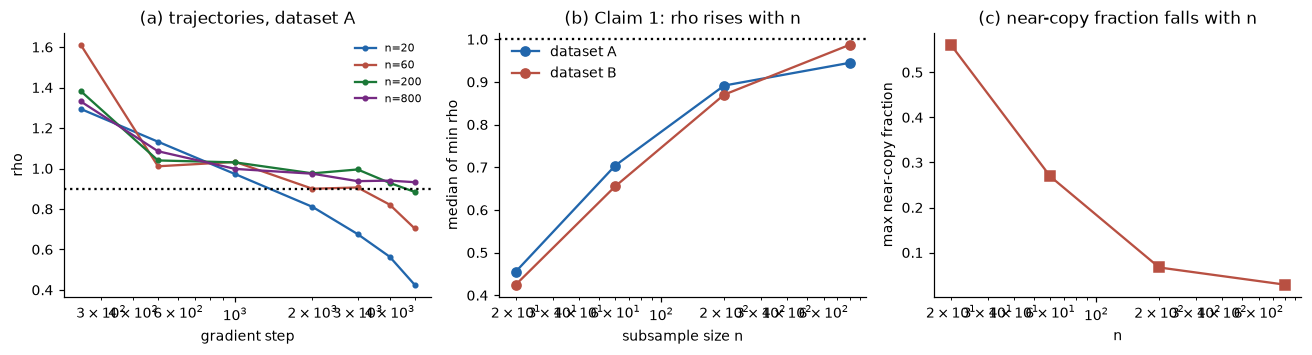

dataset  seed   n  min_rho  final_rho  tau_mem  censored
      A     0  20    0.426      0.426   2000.0     False
      A     0  60    0.705      0.705   4000.0     False
      A     0 200    0.885      0.885   5000.0     False
      A     0 800    0.932      0.932      NaN      True
      A     1  20    0.485      0.485   1000.0     False
      A     1  60    0.704      0.704   2000.0     False
      A     1 200    0.898      0.921   3000.0     False
      A     1 800    0.957      0.968      NaN      True
      B     0  20    0.532      0.532    500.0     False
      B     0  60    0.631      0.631   2000.0     False
      B     0 200    0.848      0.848   4000.0     False
      B     0 800    0.955      0.955      NaN      True
      B     1  20    0.318      0.318   2000.0     False
      B     1  60    0.680      0.680   3000.0     False
      B     1 200    0.893      0.893   5000.0     False
      B     1 800    1.019      1.019      NaN      True


In [15]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.3))
for (n, g), c in zip(TR[(TR.dataset == 'A') & (TR.seed == 0)].groupby('n'), COL):
    ax[0].semilogx(g.step, g.rho, 'o-', ms=3, color=c, label=f'n={n}')
ax[0].axhline(0.9, ls=':', c='k'); ax[0].set_xlabel('gradient step'); ax[0].set_ylabel('rho')
ax[0].set_title('(a) trajectories, dataset A'); ax[0].legend(fontsize=7)
for (dsn, g), c in zip(R.groupby('dataset'), COL):
    m_ = g.groupby('n').min_rho.median()
    ax[1].semilogx(m_.index, m_.values, 'o-', color=c, label=f'dataset {dsn}')
ax[1].axhline(1, ls=':', c='k'); ax[1].set_xlabel('subsample size n'); ax[1].set_ylabel('median of min rho')
ax[1].set_title('(b) Claim 1: rho rises with n'); ax[1].legend()
m_ = R.groupby('n').max_near_copy.median()
ax[2].semilogx(m_.index, m_.values, 's-', color=COL[1]); ax[2].set_xlabel('n'); ax[2].set_ylabel('max near-copy fraction')
ax[2].set_title('(c) near-copy fraction falls with n')
plt.tight_layout(); plt.show()
print(R[['dataset', 'seed', 'n', 'min_rho', 'final_rho', 'tau_mem', 'censored']].round(3).to_string(index=False))

### The selection effect of "minimum over checkpoints"
Reporting the minimum of a noisy trajectory is a **selection operation**: even a trajectory with no trend has a minimum below its mean, and the bias is larger when the per-checkpoint noise is larger (small *n*). The paper defends the choice by showing the conclusion is unchanged with the final-checkpoint ρ, and notes the two are near-duplicates because the minimum is usually *at* the final checkpoint (89 %).

In [16]:
g = np.random.default_rng(0)
for noise in [0.02, 0.05, 0.10]:
    traj_ = 0.5 + noise * g.normal(size=(10_000, 15))          # flat true value 0.5, 15 checkpoints
    print(f'per-checkpoint noise {noise:.2f}: E[min over 15] = {traj_.min(1).mean():.3f}  (true 0.500)')
same = (R.min_rho == R.final_rho).mean()
print(f'\nin our runs, min == final in {100*same:.0f}% of runs; '
      f'Spearman(min, final) = {st.spearmanr(R.min_rho, R.final_rho).statistic:.3f}')

per-checkpoint noise 0.02: E[min over 15] = 0.465  (true 0.500)
per-checkpoint noise 0.05: E[min over 15] = 0.413  (true 0.500)
per-checkpoint noise 0.10: E[min over 15] = 0.326  (true 0.500)

in our runs, min == final in 88% of runs; Spearman(min, final) = 1.000


### Censoring and Kaplan–Meier (paper §4.2 "Bounds")
τ-mem is a **time-to-event**: some runs never cross ρ < 0.9 within the budget (at n = 3,000, two-thirds in the paper). Dropping them and taking the median of the rest is biased — you keep only the runs that memorised fastest. **Kaplan–Meier** uses the censored runs properly: at each event time $t_j$ with $d_j$ events among $r_j$ runs still "at risk",
$$ \hat S(t) = \prod_{t_j\le t}\Big(1-\frac{d_j}{r_j}\Big), \qquad \text{KM median} = \min\{t:\hat S(t)\le 0.5\}. $$
If more than half the runs are censored, the KM median is *not reached* — the honest answer is "unknown within this budget". Below, we simulate τ-mem with a known power law $\tau \propto n^{0.75}$ so we can check which estimator recovers the true exponent.

In [17]:
def km_median(times, observed):
    times, observed = np.asarray(times, float), np.asarray(observed, bool)
    S = 1.0
    for t in np.unique(times[observed]):
        at_risk = np.sum(times >= t); d = np.sum((times == t) & observed)
        S *= 1 - d / at_risk
        if S <= 0.5: return t
    return np.nan                                        # median not reached

g = np.random.default_rng(3); budget = 25_600
ns_ = np.array([20, 50, 120, 300, 800, 1500, 3000]); true_exp = 0.75
rows = []
for n in ns_:
    tau = 120 * n ** true_exp * np.exp(0.6 * g.normal(size=40))   # true onset times
    obs = tau <= budget; t_obs = np.minimum(tau, budget)
    rows.append(dict(n=n, true_median=np.median(tau), naive_median=np.median(tau[obs]) if obs.any() else np.nan,
                     km_median=km_median(t_obs, obs), censored=1 - obs.mean()))
K = pd.DataFrame(rows); print(K.round(2).to_string(index=False))
def fit_exp(col):
    k = K.dropna(subset=[col]); return np.polyfit(np.log(k.n), np.log(k[col]), 1)[0]
print(f"\nfitted exponent: true {fit_exp('true_median'):.3f} | naive (drop censored) {fit_exp('naive_median'):.3f} | "
      f"Kaplan-Meier (estimable n only) {fit_exp('km_median'):.3f}")

   n  true_median  naive_median  km_median  censored
  20       992.32        992.32     987.46      0.00
  50      2259.62       2259.62    2227.24      0.00
 120      4965.13       4965.13    4951.77      0.00
 300      8202.82       7695.75    7707.77      0.05
 800     19937.54      14788.17   19921.19      0.45
1500     26389.86      14989.21        NaN      0.60
3000     54339.89      24011.34        NaN      0.98

fitted exponent: true 0.772 | naive (drop censored) 0.613 | Kaplan-Meier (estimable n only) 0.791


**Take-away.** Dropping censored runs biases the onset exponent **down** (the paper's earlier draft called 0.75 "a lower bound" for exactly this reason); Kaplan–Meier recovers it where the median is estimable and refuses to answer where it is not.

*Exercise 6.1.* Shrink `budget` to 5,000 and watch more sample sizes become "not reached".

---
## Module 7 — Calibration: how much of the n-effect is the metric itself? (paper §4.1)

### The problem
ρ's denominator is the held-out-to-train NN distance, and Module 2 showed it **shrinks with n**. So a generator whose behaviour *never changes* would still show ρ rising with n. How much of the observed rise is that artefact?

### The two baselines (no training required)
* **Reference sampler** — fresh real records in place of synthetic ones. ρ ≈ 1 at every n *by construction*; it anchors the scale.
* **Fixed-σ copier** — training rows plus isotropic Gaussian noise of fixed per-coordinate scale σ × (smallest-n spacing). It is a memoriser whose behaviour does not depend on n: its **numerator is flat**, so its ρ rises only by the **denominator ratio**.

### The log-scale decomposition
If the observed fold change is the product of a metric part and a behaviour part, $F_{\rm obs}=F_{\rm metric}\cdot F_{\rm behaviour}$, then
$$ \text{artefact share} = \frac{\log F_{\rm metric}}{\log F_{\rm obs}}, \qquad F_{\rm behaviour}=F_{\rm obs}/F_{\rm metric}. $$
Paper: $\log 2.31/\log 16.87 \approx 30\%$ and $16.87/2.31 = 7.3\times$ "beyond what a fixed-behaviour generator produces". Note the share must be computed on the **log** scale: 2.31/16.87 = 14 % would be wrong because fold changes multiply.

### Two subtleties the paper had to fix
1. **σ invariance.** Because the numerator is fixed, the fold change is the same at every σ — but the *level* of ρ is not.
2. **Per-coordinate vs norm.** Isotropic noise with per-coordinate SD σ in *D* dimensions has norm ≈ σ√D. With D = 21 that is 4.6σ, so at σ ≥ 0.25 the "copier" actually sits *farther* from training than held-out data (ρ > 1). Only small σ puts it in the trained models' range.

In [18]:
def copier_rho(ds, n, seed, sigma, base_spacing):
    Tn, *_ = ds.subsample(n, seed)
    rep = Rep('standard').fit(Tn); Zt, Zh = rep.transform(Tn), rep.transform(ds.H)
    g = np.random.default_rng(seed + 77)
    S = Zt[g.integers(0, len(Zt), 1000)] + sigma * base_spacing * g.normal(size=(1000, Zt.shape[1]))
    return rho_stats(S, Zt, Zh)

ns_c = sorted(set(NS + [2000]))
rows = []
for ds in (DS_A, DS_B):
    for seed in range(3):
        T20, *_ = ds.subsample(20, seed); Z20 = Rep('standard').fit(T20).transform(T20)
        base = np.median(nn_dist(Z20, Z20, True))
        for sigma in [0.02, 0.05, 0.1, 0.25]:
            for n in ns_c:
                r = copier_rho(ds, n, seed, sigma, base)
                rows.append(dict(dataset=ds.name, seed=seed, sigma=sigma, n=n, **{k: r[k] for k in ('rho', 'num', 'den')}))
CP = pd.DataFrame(rows)
ref = []
for n in ns_c:
    Tn, *_ = DS_A.subsample(n, 0); fresh, _ = make_table(9000, D=8, m=3, seed=1)
    ref.append(rho_stats(fresh[-1000:], Tn, DS_A.H)['rho'])
print('reference sampler rho by n:', np.round(ref, 3))

piv = CP.groupby(['sigma', 'n']).rho.median().unstack()
print('\ncopier median rho (rows = sigma, cols = n):'); print(piv.round(3))
fold = (CP[CP.n == ns_c[-1]].set_index(['dataset', 'seed', 'sigma']).rho /
        CP[CP.n == 20].set_index(['dataset', 'seed', 'sigma']).rho)
print('\ncopier fold change 20 ->', ns_c[-1], 'by sigma:', fold.groupby('sigma').median().round(2).to_dict(),
      '  <- (nearly) the same at every sigma')
numg = (CP[CP.n == ns_c[-1]].set_index(['dataset', 'seed', 'sigma']).num /
        CP[CP.n == 20].set_index(['dataset', 'seed', 'sigma']).num)
print('copier NUMERATOR growth, median:', round(numg.median(), 3), ' <- flat, as it must be')
print(f'norm of noise / per-coordinate scale = sqrt(D) = {np.sqrt(8):.2f} here (paper: sqrt(21) = 4.6)')

reference sampler rho by n: [0.988 0.977 0.988 0.979 1.005]

copier median rho (rows = sigma, cols = n):
n       20     60     200    800    2000
sigma                                   
0.02   0.053  0.073  0.095  0.136  0.164
0.05   0.131  0.183  0.238  0.339  0.411
0.10   0.263  0.365  0.476  0.674  0.808
0.25   0.651  0.896  1.119  1.494  1.702

copier fold change 20 -> 2000 by sigma: {0.02: 3.17, 0.05: 3.17, 0.1: 3.11, 0.25: 2.66}   <- (nearly) the same at every sigma
copier NUMERATOR growth, median: 0.993  <- flat, as it must be
norm of noise / per-coordinate scale = sqrt(D) = 2.83 here (paper: sqrt(21) = 4.6)


### Compare with the trained models — like with like
Now match spans: take cells that contain both n = 20 and a larger n, and compare the trained models' fold change with the copier's. The paper uses a **Mann–Whitney U test** on cell-level fold changes — a rank test that asks whether one group's values tend to be larger, without assuming normality.

In [19]:
def fold_changes(df, n_hi, val, keys=('dataset', 'seed')):
    a = df[df.n == 20].set_index(list(keys))[val]; b = df[df.n == n_hi].set_index(list(keys))[val]
    return (b / a).dropna()

# pick the copier noise level whose rho at n = 20 is closest to the trained models' (levels differ, folds do not)
lvl = CP[CP.n == 20].groupby('sigma').rho.median()
sig = (lvl - R[R.n == 20].min_rho.median()).abs().idxmin()
print(f'copier sigma matched to the models at n = 20: sigma = {sig}  (copier rho {lvl[sig]:.3f} vs models {R[R.n == 20].min_rho.median():.3f})\n')
rows = []
for hi in NS[1:]:
    fm = fold_changes(R, hi, 'min_rho')
    fc = fold_changes(CP[CP.sigma == sig], hi, 'rho', keys=('dataset', 'seed'))
    Fo, Fm = fm.median(), fc.median()
    rows.append(dict(span=f'20 -> {hi}', trained_fold=Fo, copier_fold=Fm,
                     mann_whitney_p=st.mannwhitneyu(fm, fc).pvalue,
                     artefact_share_log=np.log(Fm) / np.log(Fo) if Fo > 1.05 else np.nan,
                     behavioural_part=Fo / Fm, cells=f'{len(fm)} vs {len(fc)}'))
CAL = pd.DataFrame(rows); print(CAL.round(3).to_string(index=False))
last = CAL.iloc[-1]
if last.copier_fold >= last.trained_fold:
    print(f"\nwidest span: the copier rises {last.copier_fold:.2f}x and the trained models only {last.trained_fold:.2f}x"
          " -> the metric alone can explain the WHOLE rise; nothing is credited to the models.")
else:
    print(f"\nwidest span: artefact share = log {last.copier_fold:.2f} / log {last.trained_fold:.2f} = {last.artefact_share_log:.0%}"
          f"  (the WRONG linear share would be {last.copier_fold/last.trained_fold:.0%})")
print('paper, for comparison: 20 -> 3,000 on CDC diabetes, trained 16.87x vs copier 2.31x, share 30%, behavioural part 7.3x')

copier sigma matched to the models at n = 20: sigma = 0.1  (copier rho 0.263 vs models 0.456)

     span  trained_fold  copier_fold  mann_whitney_p  artefact_share_log  behavioural_part  cells
 20 -> 60         1.552        1.384           0.352               0.740             1.121 4 vs 6
20 -> 200         1.964        1.813           0.352               0.882             1.083 4 vs 6
20 -> 800         2.080        2.582           0.352               1.295             0.806 4 vs 6

widest span: the copier rises 2.58x and the trained models only 2.08x -> the metric alone can explain the WHOLE rise; nothing is credited to the models.
paper, for comparison: 20 -> 3,000 on CDC diabetes, trained 16.87x vs copier 2.31x, share 30%, behavioural part 7.3x


**How to read the table.** `behavioural_part` > 1 means the trained models' ρ rose by more than a fixed-behaviour generator's would; ≤ 1 means the whole rise is explainable by the metric. With only a handful of cells per span, the Mann–Whitney p-values are weak — the paper had the same problem at its smallest span (p = 0.058) and withdrew the claim there. A blank `artefact_share_log` means the trained models barely moved, so the share is undefined.

**Why the toy may credit nothing to the models — and why that is the calibration working.** The paper's models copied almost perfectly at n = 20 (ρ ≈ 0.05) and reached ρ ≈ 0.96 at n = 3,000: a 17× rise that a fixed copier (2.3×) cannot produce. Our toy models, trained for 5,000 instead of 25,600 steps, copy only partly at n = 20 (ρ ≈ 0.3–0.5), so their rise is a few-fold — about what the shrinking denominator produces on its own, especially on a table with low intrinsic dimension where spacing shrinks fast (Module 2). The calibration then correctly refuses to credit the models: their n-trend is **real in ρ but not distinguishable from the metric's drift** — exactly the paper's own conclusion for its small spans (p = 0.058). Two things change the verdict, and you can test both:
* train longer so small-n models copy deeply (Exercise 7.3), which raises the trained fold;
* use a table of higher intrinsic dimension, which shrinks the copier's fold (spacing ∝ n^(−1/m)).

**Take-away.** The calibration turns "ρ rises with n" into "ρ rises with n *by more than the metric alone can produce*", with the artefact quantified. The paper also reports the limitation honestly: at small spans (n = 20 → 120) trained models and the copier were **not distinguishable** (p = 0.058), so it withdraws any claim about that regime.

*Exercise 7.1.* Recompute the comparison for n = 20 → 50 only. Can you distinguish the trained models from the copier there?

*Exercise 7.2.* Prove that if the copier's numerator is exactly constant, its fold change equals the denominator ratio for every σ (one line of algebra).

*Exercise 7.3.* Set `STEPS = 20000` and `CKPTS = [500, 1000, 2000, 4000, 8000, 12000, 16000, 20000]`, rerun Modules 6–7 for dataset B only, and check whether `behavioural_part` rises above 1.

---
## Module 8 — Claim 2 experiment: dimension within a projection family

### Design
Hold dataset, *n* and seed fixed; vary only the projection dimension *d* inside one family. Do it for **PCA** (fitted) and **random projection** (data-independent). Within each (dataset, n, seed) cell, compute
* the **Spearman correlation** between d and ρ, and
* the **slope** of ρ on d, scaled to "per ten dimensions" (the paper's interpretable unit).

Then check the **shape**: the paper found a U (minimum at intermediate d), confirmed by bootstrapping the ratio $\bar\rho(d_{\rm end})/\bar\rho(d_{\min})$ over balanced cells, and checked against a **dimension copier** whose noise is scaled by $1/\sqrt d$ per coordinate so its total norm is constant across d.

We use a 12-column table so dimension can vary from 3 to 12.

In [20]:
DS_C = Dataset('C', D=12, m=4, seed=5)
DIMS = [3, 6, 9, 12]
NS_D = [60] if not FAST else [60]
SEEDS_D = [0, 1, 2] if not FAST else [0, 1]
STEPS_D = 3000 if not FAST else 2000
CK_D = [s for s in CKPTS if s <= STEPS_D]
drows = []; t0 = time.time()
for fam in ['pca', 'randproj']:
    for n in NS_D:
        for seed in SEEDS_D:
            Tn, yTn, *_ = DS_C.subsample(n, seed)
            for d in DIMS:
                rep = Rep(fam, d, seed=seed).fit(Tn)
                Zt, Zh = rep.transform(Tn), rep.transform(DS_C.H)
                net, log = train_ddpm(Zt, yTn, STEPS_D, CK_D, seed=seed, on_checkpoint=make_eval(Zt, Zh))
                tr = pd.DataFrame(log)
                drows.append(dict(dataset='C', family=fam, n=n, seed=seed, d=d, min_rho=tr.rho.min(),
                                  clamp=tr.clamp.mean(), coord_sd=Zt.std()))
            print(f'{fam:8s} n={n} seed={seed} done [{time.time()-t0:.0f}s]')
DM = pd.DataFrame(drows)
print(DM.pivot_table(index=['family', 'n', 'seed'], columns='d', values='min_rho').round(3))
print('\nclamp share by family and d (mean):'); print(DM.pivot_table(index='family', columns='d', values='clamp').round(4))

pca      n=60 seed=0 done [37s]


pca      n=60 seed=1 done [75s]


pca      n=60 seed=2 done [113s]


randproj n=60 seed=0 done [152s]


randproj n=60 seed=1 done [190s]


randproj n=60 seed=2 done [229s]
d                    3      6      9      12
family   n  seed                            
pca      60 0     0.720  0.782  0.803  0.793
            1     0.712  0.715  0.803  0.795
            2     0.753  0.681  0.715  0.754
randproj 60 0     0.903  0.750  0.842  0.829
            1     0.727  0.694  0.691  0.778
            2     0.684  0.724  0.700  0.808

clamp share by family and d (mean):
d             3       6       9       12
family                                  
pca       0.0294  0.0274  0.0336  0.0318
randproj  0.0333  0.0278  0.0373  0.0383


In [21]:
def boot(v, B=10_000, seed=0, stat=np.mean):
    v = np.asarray(v); g = np.random.default_rng(seed)
    b = np.array([stat(v[g.integers(0, len(v), len(v))]) for _ in range(B)])
    return np.percentile(b, [2.5, 97.5])

print('family     Spearman(d,rho) per cell -> mean [95% CI]      slope per 10 dims -> mean [95% CI]')
for fam, g in DM.groupby('family'):
    rs, sl = [], []
    for _, c in g.groupby(['n', 'seed']):
        rs.append(st.spearmanr(c.d, c.min_rho).statistic)
        sl.append(10 * st.linregress(c.d, c.min_rho).slope)
    rs, sl = np.array(rs), np.array(sl)
    print(f'{fam:9s}  {rs.mean():+.3f} {np.round(boot(rs), 3)}        {sl.mean():+.4f} {np.round(boot(sl), 4)}   ({len(rs)} cells)')

# shape: ratio of each end to the minimum, bootstrapped over cells
for fam, g in DM.groupby('family'):
    M = g.pivot_table(index=['n', 'seed'], columns='d', values='min_rho').values
    gb = np.random.default_rng(0); L, Rr = [], []
    for _ in range(5000):
        s = M[gb.integers(0, len(M), len(M))].mean(0); k = s.argmin()
        L.append(s[0] / s[k]); Rr.append(s[-1] / s[k])
    print(f'{fam:9s} mean rho by d {np.round(M.mean(0), 3)} | rho(d_first)/rho(min) {np.percentile(L,[50,2.5,97.5]).round(2)} '
          f'| rho(d_last)/rho(min) {np.percentile(Rr,[50,2.5,97.5]).round(2)}')

family     Spearman(d,rho) per cell -> mean [95% CI]      slope per 10 dims -> mean [95% CI]


pca        +0.667 [0.4 0.8]        +0.0685 [0.0129 0.1122]   (3 cells)


randproj   +0.200 [-0.4  0.8]        +0.0410 [-0.0438  0.1164]   (3 cells)
pca       mean rho by d [0.728 0.726 0.774 0.781] | rho(d_first)/rho(min) [1.   1.   1.11] | rho(d_last)/rho(min) [1.11 1.07 1.12]
randproj  mean rho by d [0.771 0.723 0.744 0.805] | rho(d_first)/rho(min) [1.07 1.   1.2 ] | rho(d_last)/rho(min) [1.11 1.11 1.18]


**How to read this.** With only a few cells, the intervals are wide — that is the lesson about **power**, not a failure. Worse, a bootstrap over 3 cells has only 10 distinct resamples, so its "95 % interval" is not trustworthy at all: never read a bootstrap CI from a handful of units. The paper had 39 cells per family and still found the PCA correlation's *sign* flipping with the cell-inclusion rule (−0.092, +0.073, +0.158), which it rightly reads as "how little signal is present". A ratio CI that includes 1 means "no detectable dip"; one that excludes 1 means "the dip is real".

### The dimension copier: is ρ itself dimension-dependent?
Per-coordinate noise σ · spacing / √d gives total noise norm σ · spacing at every d, so the copier's *behaviour* is constant across d. The noise must be added in **the space ρ is computed in** (the standardised representation space): add it before standardising and the standardisation stretches it unevenly across PCA components, which is no longer "fixed behaviour". Any drift in its ρ is the metric's doing. A **monotone** drift cannot create a **dip** — so if the models dip and the copier rises monotonically, the shape belongs to the models. The paper also divides the observed curve by the copier curve ("drift-corrected") and checks the shape survives.

In [22]:
rows = []
for fam in ['pca', 'randproj']:
    for seed in range(3):
        Tn, *_ = DS_C.subsample(240, seed)
        for d in DIMS:
            rep = Rep(fam, d, seed=seed).fit(Tn)
            Zt, Zh = standardise_by(rep.transform(Tn), rep.transform(DS_C.H))   # rho's own space
            sp = np.median(nn_dist(Zt, Zt, True)); g = np.random.default_rng(seed)
            for sigma in [0.1, 0.25, 0.5]:
                S = Zt[g.integers(0, len(Zt), 1000)] + g.normal(size=(1000, d)) * sigma * sp / np.sqrt(d)
                rows.append(dict(family=fam, seed=seed, d=d, sigma=sigma,
                                 rho=rho_stats(S, Zt, Zh, standardise=False)['rho']))
DC = pd.DataFrame(rows)
cop = DC.groupby(['family', 'sigma', 'd']).rho.median().unstack()
print('dimension copier, median rho:'); print(cop.round(3))
print('\nswing (max/min) and argmin per row:')
for idx, r in cop.iterrows(): print(f'  {idx}: swing {r.max()/r.min():.2f}x, argmin d={r.idxmin()}')
obs = DM.groupby(['family', 'd']).min_rho.mean().unstack()
corr = obs / cop.xs(0.25, level='sigma') * cop.xs(0.25, level='sigma')[DIMS[0]].values[:, None]
print('\nobserved mean rho:'); print(obs.round(3)); print('drift-corrected (observed / copier, rescaled to first d):'); print(corr.round(3))

dimension copier, median rho:
d                  3      6      9      12
family   sigma                            
pca      0.10   0.097  0.096  0.098  0.095
         0.25   0.241  0.240  0.241  0.237
         0.50   0.469  0.475  0.482  0.477
randproj 0.10   0.092  0.092  0.091  0.093
         0.25   0.227  0.229  0.227  0.232
         0.50   0.442  0.451  0.449  0.471

swing (max/min) and argmin per row:
  ('pca', 0.1): swing 1.03x, argmin d=12
  ('pca', 0.25): swing 1.02x, argmin d=12
  ('pca', 0.5): swing 1.03x, argmin d=3
  ('randproj', 0.1): swing 1.01x, argmin d=9
  ('randproj', 0.25): swing 1.02x, argmin d=3
  ('randproj', 0.5): swing 1.07x, argmin d=3

observed mean rho:
d            3      6      9      12
family                              
pca       0.728  0.726  0.774  0.781
randproj  0.771  0.723  0.744  0.805
drift-corrected (observed / copier, rescaled to first d):
d            3      6      9      12
family                              
pca       0.728  0.729  0.773 

### The clamp confound — a test the paper did not run, and you can
The paper's only significant dimension result (random-projection slope > 0) has a candidate mechanical explanation: the [−5, 5] clamp binds more at low d for random projection because coordinate SD ≈ √(D/d). The decisive experiment is to **rerun the random-projection sweep with the clamp removed** (`clamp=np.inf`) and see whether the slope changes. Here is the scaffold:

In [23]:
def rp_sweep(clamp, n=240, seed=0, steps=STEPS_D):
    Tn, yTn, *_ = DS_C.subsample(n, seed); out = []
    for d in DIMS:
        rep = Rep('randproj', d, seed=seed).fit(Tn); Zt, Zh = rep.transform(Tn), rep.transform(DS_C.H)
        def ev(net):
            S, _, cl = sample_net(net, d, clamp=clamp); r = rho_stats(S, Zt, Zh); return dict(rho=r['rho'], clamp=cl)
        _, log = train_ddpm(Zt, yTn, steps, CK_D, seed=seed, on_checkpoint=ev)
        out.append(dict(d=d, coord_sd=Zt.std(), clamp_share=np.mean([L['clamp'] for L in log]),
                        min_rho=min(L['rho'] for L in log)))
    return pd.DataFrame(out)
print('coordinate SD of random-projection space by d (theory sqrt(D/d)):',
      {d: round(float(np.sqrt(12 / d)), 2) for d in DIMS})
cl = DM.pivot_table(index='family', columns='d', values='clamp')
print('measured clamp share (averaged over all 100 reverse steps and checkpoints):'); print(cl.round(4))
trend = cl.loc['randproj'].iloc[0] / max(cl.loc['randproj'].iloc[-1], 1e-9)
print(f'random projection, clamp share at d={DIMS[0]} vs d={DIMS[-1]}: {trend:.2f}x. '
      + ('It barely changes with d here, so the clamp cannot drive a dimension trend in this toy.' if trend < 1.5 else
         'It grows as d falls, so the clamp could contribute to a dimension trend here.'))
print('Most of this clamping happens at the noisiest early reverse steps. With only 12 columns, sqrt(D/d) is at most 2;')
print('on the paper\'s 21-30 column tables it reaches 2.3-2.7, and the share of clamped coordinates at d=4 is ~3%.')
print('Exercise 8.1 asks you to run rp_sweep(5.0) vs rp_sweep(np.inf) on a wider table.')

coordinate SD of random-projection space by d (theory sqrt(D/d)): {3: 2.0, 6: 1.41, 9: 1.15, 12: 1.0}
measured clamp share (averaged over all 100 reverse steps and checkpoints):
d             3       6       9       12
family                                  
pca       0.0294  0.0274  0.0336  0.0318
randproj  0.0333  0.0278  0.0373  0.0383
random projection, clamp share at d=3 vs d=12: 0.87x. It barely changes with d here, so the clamp cannot drive a dimension trend in this toy.
Most of this clamping happens at the noisiest early reverse steps. With only 12 columns, sqrt(D/d) is at most 2;
on the paper's 21-30 column tables it reaches 2.3-2.7, and the share of clamped coordinates at d=4 is ~3%.
Exercise 8.1 asks you to run rp_sweep(5.0) vs rp_sweep(np.inf) on a wider table.


*Exercise 8.1.* Build `DS_W = Dataset('W', D=24, m=5, seed=9)`, change `DS_C` to `DS_W` inside `rp_sweep`, use `DIMS = [4, 8, 16, 24]`, and compare `rp_sweep(5.0)` with `rp_sweep(np.inf)`. If the slope of min ρ on d shrinks without the clamp, the paper's random-projection association was (partly) the clamp.

*Exercise 8.2.* Replace the independent random matrix per d with a **nested** design: draw one 24×24 orthonormal basis and use its first d columns. The paper notes that independent matrices vary "dimension and projection realisation together".

---
## Module 9 — The statistics toolkit, tested on simulated result tables with known truth

Our toy experiments are small, so to *understand the statistics* we simulate **result tables** like the paper's 822-run file, with effects we choose. Then we can ask of each method: does it recover the truth, and when does it mislead?

The simulated grid has 4 datasets with **uneven sample-size coverage** (like the paper: two small tables stop at n = 120, one at 300, one reaches 3,000), 5 families, PCA/RP at several dimensions, 3 seeds, a strong log-n effect, a small true dimension effect, and **cell-level random effects** (runs in the same cell share a shift).

In [24]:
def simulate_grid(beta_logn=0.12, beta_dim=0.0, cell_sd=0.04, noise_sd=0.03, seed=0, dims=(4, 8, 12, 16, 21)):
    g = np.random.default_rng(seed)
    cover = {'big': [20, 50, 120, 300, 800, 1500, 3000], 'mid': [20, 50, 120, 300],
             'small1': [20, 50, 120], 'small2': [20, 50, 120]}
    base = {'big': -0.05, 'mid': 0.02, 'small1': 0.05, 'small2': 0.0}
    rows = []
    for ds, ns in cover.items():
        for fam in ['standard', 'quantile', 'autoencoder', 'pca', 'randproj']:
            ds_dims = dims if fam in ('pca', 'randproj') else ([8] if fam == 'autoencoder' else [21])
            for d in ds_dims:
                for seed in range(3):
                    u = g.normal(0, cell_sd)                         # cell random effect
                    for n in ns:
                        rho = base[ds] + u + beta_logn * np.log(n / 20) + beta_dim * d + g.normal(0, noise_sd)
                        rows.append(dict(dataset=ds, family=fam, dim=d, seed=seed, n=n,
                                         rho=np.clip(rho + 0.06, 0.01, None)))
    return pd.DataFrame(rows)

G = simulate_grid(beta_dim=0.001)
print(G.shape, 'runs'); print(G.groupby('dataset').n.agg(['min', 'max', 'nunique']))

(663, 6) runs
         min   max  nunique
dataset                    
big       20  3000        7
mid       20   300        4
small1    20   120        3
small2    20   120        3


### 9.1 The experimental cell and within-cell Spearman
A **cell** = (dataset, family, dimension, seed). Within a cell only *n* varies. The paper's primary estimand is the **unweighted mean of cell-level Spearman coefficients**, with cells requiring ≥ 3 sample sizes.

### 9.2 Spearman saturation
Spearman's ρ_s is a correlation of ranks. With *k* points it can only take a few values; with *k* = 3 only **{−1, −0.5, +0.5, +1}**. Any monotone relationship gives exactly 1 — a **ceiling**. That is why the paper's outer-partition result (exactly 1.000 in all 80 cells) "shows direction but does not bound magnitude", and why it also reports the **within-cell slope** of ρ on log n, which does not saturate.

In [25]:
for k in [3, 4, 5, 7]:
    vals = sorted({round(st.spearmanr(range(k), p).statistic, 3) for p in itertools.permutations(range(k))})
    print(f'k={k}: {len(vals):3d} possible Spearman values, e.g. {vals[:3]} ... {vals[-3:]}')

def cell_stats(df, x='n', y='rho', keys=('dataset', 'family', 'dim', 'seed'), k=3, logx=True):
    rs, sl = [], []
    for _, c in df.groupby(list(keys)):
        if c[x].nunique() >= k:
            rs.append(st.spearmanr(c[x], c[y]).statistic)
            sl.append(st.linregress(np.log(c[x]) if logx else c[x], c[y]).slope)
    return np.array(rs), np.array(sl)

rs, sl = cell_stats(G)
print(f'\nwithin-cell Spearman: mean {rs.mean():+.3f}, CI {boot(rs).round(3)}, {len(rs)} cells, {100*(rs>0).mean():.1f}% positive')
print(f'within-cell slope on log n: mean {sl.mean():+.4f} (true 0.120), CI {boot(sl).round(4)}')
print('-> the Spearman is near its ceiling and says little about SIZE; the slope recovers the true effect.')

k=3:   4 possible Spearman values, e.g. [np.float64(-1.0), np.float64(-0.5), np.float64(0.5)] ... [np.float64(-0.5), np.float64(0.5), np.float64(1.0)]
k=4:  11 possible Spearman values, e.g. [np.float64(-1.0), np.float64(-0.8), np.float64(-0.6)] ... [np.float64(0.6), np.float64(0.8), np.float64(1.0)]
k=5:  21 possible Spearman values, e.g. [np.float64(-1.0), np.float64(-0.9), np.float64(-0.8)] ... [np.float64(0.8), np.float64(0.9), np.float64(1.0)]


k=7:  57 possible Spearman values, e.g. [np.float64(-1.0), np.float64(-0.964), np.float64(-0.929)] ... [np.float64(0.929), np.float64(0.964), np.float64(1.0)]



within-cell Spearman: mean +0.997, CI [0.99 1.  ], 156 cells, 100.0% positive
within-cell slope on log n: mean +0.1188 (true 0.120), CI [0.116  0.1216]
-> the Spearman is near its ceiling and says little about SIZE; the slope recovers the true effect.


### 9.3 Bootstrap over cells, not runs (pseudo-replication)
Runs in a cell share a random effect, so they are **not independent**. Resampling runs as if they were independent makes intervals far too narrow. The **percentile bootstrap** over cells: resample cells with replacement B = 10,000 times, recompute the mean, take the 2.5th and 97.5th percentiles.

In [26]:
# 150 cells x 4 runs. Each cell has its own random shift u (sd 0.10); runs inside a cell differ
# only by small noise (sd 0.02). The true population mean is 0.5.
def two_level(seed, n_cells=150, runs=4, cell_sd=0.10, run_sd=0.02):
    g = np.random.default_rng(seed)
    u = g.normal(0, cell_sd, n_cells)
    return pd.DataFrame({'cell': np.repeat(np.arange(n_cells), runs),
                         'rho': 0.5 + np.repeat(u, runs) + g.normal(0, run_sd, n_cells * runs)})
Gc = two_level(0)
cells = Gc.groupby('cell').rho.mean().values
print('mean rho, bootstrap over RUNS :', boot(Gc.rho.values).round(4), f'(width {np.ptp(boot(Gc.rho.values)):.4f})')
print('mean rho, bootstrap over CELLS:', boot(cells).round(4), f'(width {np.ptp(boot(cells)):.4f})')
hits_run = hits_cell = 0
for k in range(200):
    Gs = two_level(100 + k)
    lo, hi = boot(Gs.rho.values, B=500, seed=k); hits_run += lo <= 0.5 <= hi
    lo, hi = boot(Gs.groupby('cell').rho.mean().values, B=500, seed=k); hits_cell += lo <= 0.5 <= hi
print(f'coverage of a nominal 95% interval over 200 simulated studies:  runs {hits_run/200:.0%}   |   cells {hits_cell/200:.0%}')
print('-> resampling runs ignores the shared cell effects, so its interval is far too narrow.')

mean rho, bootstrap over RUNS : [0.4973 0.5131] (width 0.0158)


mean rho, bootstrap over CELLS: [0.4895 0.5205] (width 0.0310)


coverage of a nominal 95% interval over 200 simulated studies:  runs 60%   |   cells 94%
-> resampling runs ignores the shared cell effects, so its interval is far too narrow.


### 9.4 Partial R² — and why "45× stronger" partly restates the design
$$ R^2_{\text{partial}}(X_j) = \frac{R^2_{\text{full}} - R^2_{\text{reduced}}}{1 - R^2_{\text{reduced}}}, $$
where the reduced model drops $X_j$ and keeps every other covariate. It is the share of the variance *left unexplained by the others* that $X_j$ explains. Crucially, it depends on **how much $X_j$ varies in the design**: the same true slope explains more variance if you sweep a wider range. The paper concedes this ("n spans 150× on a log scale while dimension spans about 5× linearly … the comparison partly restates the design"). Watch it happen:

In [27]:
def partial_r2(df, term, formula_rest):
    full = smf.ols(f'rho ~ {term} + {formula_rest}', df).fit()
    red = smf.ols(f'rho ~ {formula_rest}', df).fit()
    return (full.rsquared - red.rsquared) / (1 - red.rsquared)

for dims in [(8, 12), (4, 8, 12, 16, 21), (2, 16, 32, 64)]:
    Gd = simulate_grid(beta_dim=0.004, dims=dims, seed=1); Gd['logn'] = np.log(Gd.n)
    print(f'dimension swept over {dims}: partial R2  log n {partial_r2(Gd, "logn", "dim + C(dataset) + C(family)"):.3f}  '
          f'| dimension {partial_r2(Gd, "dim", "logn + C(dataset) + C(family)"):.4f}   (same true dimension slope every time)')

dimension swept over (8, 12): partial R2  log n 0.922  | dimension 0.0318   (same true dimension slope every time)
dimension swept over (4, 8, 12, 16, 21): partial R2  log n 0.905  | dimension 0.0706   (same true dimension slope every time)
dimension swept over (2, 16, 32, 64): partial R2  log n 0.918  | dimension 0.7415   (same true dimension slope every time)


### 9.5 Cluster-robust standard errors and block permutation tests
OLS standard errors assume independent rows. With repeated measures inside cells, they are too small (the paper's naive p-value for log n was 3 × 10⁻¹⁵², "implausibly small"). Two fixes:
* **Cluster-robust (sandwich) SEs**, clustering at the cell level.
* **Block permutation:** shuffle a predictor *only within blocks where it actually varies* (log n within cells; dimension within (dataset, n, seed) blocks), recompute the statistic, and see where the observed value falls. With B permutations the smallest attainable p-value is 1/(B+1).

In [28]:
Gp = simulate_grid(beta_dim=0.0, cell_sd=0.08, seed=4); Gp['logn'] = np.log(Gp.n)
Gp['cell'] = Gp.groupby(['dataset', 'family', 'dim', 'seed']).ngroup()
ols = smf.ols('rho ~ logn + dim + C(dataset) + C(family)', Gp).fit()
clu = smf.ols('rho ~ logn + dim + C(dataset) + C(family)', Gp).fit(cov_type='cluster', cov_kwds={'groups': Gp.cell})
print(f"dimension coef (true 0): {ols.params['dim']:+.5f}  naive SE {ols.bse['dim']:.5f} p={ols.pvalues['dim']:.3f} | "
      f"cluster SE {clu.bse['dim']:.5f} p={clu.pvalues['dim']:.3f}")

def slope(x, y): return np.polyfit(x, y, 1)[0]

def perm_p(df, how, B=200, seed=0):
    '''Permutation p-value for the slope of rho on dim, shuffling at one of two levels.'''
    g = np.random.default_rng(seed); y = df.rho.values; x = df.dim.values.astype(float)
    obs = slope(x, y)
    if how == 'rows':      # the paper's scheme: shuffle dim among runs within (dataset, n, seed)
        groups = list(df.groupby(['dataset', 'n', 'seed']).indices.values())
    else:                  # shuffle dim labels among CELLS within (dataset, family, seed)
        cell = df.groupby(['dataset', 'family', 'dim', 'seed']).ngroup().values
        cell_dim = df.groupby(cell).dim.first().values.astype(float)
        cgroups = list(df.groupby(cell).first().reset_index().groupby(['dataset', 'family', 'seed']).indices.values())
    null = np.empty(B)
    for b in range(B):
        if how == 'rows':
            xp = x.copy()
            for ix in groups: xp[ix] = x[g.permutation(ix)]
        else:
            cd = cell_dim.copy()
            for ix in cgroups: cd[ix] = cell_dim[g.permutation(ix)]
            xp = cd[cell]
        null[b] = slope(xp, y)
    return (1 + np.sum(np.abs(null) >= abs(obs))) / (B + 1)

pp = Gp[Gp.family.isin(['pca', 'randproj'])].reset_index(drop=True)
print(f"one simulated grid (true dimension effect = 0): p, shuffle rows within (dataset,n,seed) = {perm_p(pp, 'rows'):.3f} | "
      f"shuffle cells within (dataset,family,seed) = {perm_p(pp, 'cells'):.3f}")

fp = {'rows': 0, 'cells': 0}; R_SIM = 25 if not FAST else 10
for k in range(R_SIM):
    Gk = simulate_grid(beta_dim=0.0, cell_sd=0.08, seed=200 + k)
    Gk = Gk[Gk.family.isin(['pca', 'randproj'])].reset_index(drop=True)
    for how in fp: fp[how] += perm_p(Gk, how, B=100, seed=k) < 0.05
print(f"false-positive rate at alpha = 0.05 over {R_SIM} null grids: rows-within-(dataset,n,seed) {fp['rows']/R_SIM:.0%} | "
      f"cells-within-(dataset,family,seed) {fp['cells']/R_SIM:.0%}   (nominal 5%)")

dimension coef (true 0): +0.00216  naive SE 0.00060 p=0.000 | cluster SE 0.00134 p=0.107


one simulated grid (true dimension effect = 0): p, shuffle rows within (dataset,n,seed) = 0.005 | shuffle cells within (dataset,family,seed) = 0.085


false-positive rate at alpha = 0.05 over 25 null grids: rows-within-(dataset,n,seed) 40% | cells-within-(dataset,family,seed) 8%   (nominal 5%)


**The lesson: permute at the level where the predictor was assigned.** A permutation test is valid only if the shuffled units are *exchangeable* under the null. Dimension is assigned to a whole **cell** (every run in a cell shares its dimension *and* its random cell effect). Shuffling dimension among individual runs within (dataset, n, seed) breaks the link between a cell's dimension and its random effect at each n separately, while the observed data keep that link at every n — so chance alignment between cell effects and dimension looks "significant" too often. Shuffling dimension labels among **cells** keeps each cell intact and holds its nominal rate.

**For the paper.** Its dimension test shuffled within (dataset × n × seed) blocks and found p = 0.108 — not significant. Because that scheme errs toward false positives, the true p-value would be *larger*, so the paper's conclusion (no evidence for a dimension effect) is, if anything, conservative. But a reviewer who knows permutation tests could point out that the scheme is not the right one; the cell-level version is easy to add.

### 9.6 Simpson's paradox: the spacing confound (paper, earlier drafts)
An earlier draft found "wider training-set spacing goes with lower ρ" when pooled — then saw the sign reverse within fixed *n*. Spacing is almost a deterministic function of *n*, so the pooled correlation was just sample size in disguise.

In [29]:
g = np.random.default_rng(0); rows = []
for n in [20, 50, 120, 300, 800, 3000]:
    for i in range(30):
        spacing = 3.0 * n ** -0.12 + 0.05 * g.normal()               # spacing falls with n
        rho = 0.1 + 0.12 * np.log(n / 20) + 0.3 * (spacing - 3.0 * n ** -0.12) + 0.03 * g.normal()
        rows.append(dict(n=n, spacing=spacing, rho=rho))
Sp = pd.DataFrame(rows)
print(f"pooled Spearman(spacing, rho) = {st.spearmanr(Sp.spacing, Sp.rho).statistic:+.3f}")
print(f"within-n mean Spearman       = {np.mean([st.spearmanr(g_.spacing, g_.rho).statistic for _, g_ in Sp.groupby('n')]):+.3f}")
print('-> the pooled sign is the opposite of the within-n relationship: a Simpson reversal.')

pooled Spearman(spacing, rho) = -0.952
within-n mean Spearman       = +0.470
-> the pooled sign is the opposite of the within-n relationship: a Simpson reversal.


### 9.7 Composition confounding in pooled curves
If datasets cover different sample-size ranges, a pooled median "by n" changes **which datasets** it averages as n grows. Part of any trend is then the dataset mix. The paper's augmentation table was the clearest case: the apparent "augmentation gets worse with n" was CDC diabetes taking over the larger-n rows; within CDC the effect was flat.

In [30]:
g = np.random.default_rng(1); rows = []
level = {'big': -0.006, 'small1': 0.000, 'small2': 0.001}           # per-dataset effect, FLAT in n
cover = {'big': [50, 120, 300, 800, 1500, 3000], 'small1': [50, 120], 'small2': [50, 120, 300]}
for ds, ns in cover.items():
    for n in ns:
        for _ in range(40): rows.append(dict(dataset=ds, n=n, dAUC=level[ds] + 0.003 * g.normal()))
A_ = pd.DataFrame(rows)
print('pooled mean dAUC by n:', A_.groupby('n').dAUC.mean().round(4).to_dict())
print('within "big" only    :', A_[A_.dataset == 'big'].groupby('n').dAUC.mean().round(4).to_dict())
print('-> the pooled "trend" is entirely composition; every dataset is flat in n.')

pooled mean dAUC by n: {50: -0.002, 120: -0.0017, 300: -0.0025, 800: -0.0067, 1500: -0.0059, 3000: -0.0066}
within "big" only    : {50: -0.006, 120: -0.0064, 300: -0.006, 800: -0.0067, 1500: -0.0059, 3000: -0.0066}
-> the pooled "trend" is entirely composition; every dataset is flat in n.


### 9.8 Testing shape: Friedman vs a curvature contrast vs a bootstrap ratio
The **Friedman test** (rank-based repeated-measures ANOVA) asks whether *any* dimension level differs — it is equally happy with a monotone trend and a U. To claim a **dip** you need a test of shape: a quadratic contrast, or — the paper's choice — a bootstrap CI on $\bar\rho(\text{end})/\bar\rho(\text{minimum})$ excluding 1 at both ends.

In [31]:
g = np.random.default_rng(2); d_ = np.array([4, 8, 12, 16, 21])
monotone = 0.25 + 0.006 * d_ + 0.02 * g.normal(size=(24, 5))
ushape = 0.30 + 0.0012 * (d_ - 9) ** 2 + 0.02 * g.normal(size=(24, 5))
for name, M in [('monotone', monotone), ('U-shape', ushape)]:
    fr = st.friedmanchisquare(*M.T).pvalue
    q = np.array([2, -1, -2, -1, 2])                                      # orthogonal quadratic contrast
    qc = M @ q; tq = st.ttest_1samp(qc, 0).pvalue
    gb = np.random.default_rng(0); L, Rr = [], []
    for _ in range(4000):
        s = M[gb.integers(0, 24, 24)].mean(0); L.append(s[0] / s.min()); Rr.append(s[-1] / s.min())
    print(f'{name:9s}: Friedman p={fr:.1e} | quadratic contrast p={tq:.1e} | '
          f'ratio first/min CI {np.percentile(L,[2.5,97.5]).round(2)} last/min CI {np.percentile(Rr,[2.5,97.5]).round(2)}')
print('-> Friedman rejects for BOTH; only the shape tests separate them (for the monotone curve, the\n'
      '   minimum is at an end, so one ratio is exactly 1 and its interval cannot exclude 1).')

monotone : Friedman p=1.2e-15 | quadratic contrast p=5.4e-02 | ratio first/min CI [1. 1.] last/min CI [1.28 1.37]


U-shape  : Friedman p=1.4e-16 | quadratic contrast p=1.8e-15 | ratio first/min CI [1.07 1.16] last/min CI [1.52 1.64]
-> Friedman rejects for BOTH; only the shape tests separate them (for the monotone curve, the
   minimum is at an end, so one ratio is exactly 1 and its interval cannot exclude 1).


### 9.9 A "bounded null": what a confidence interval excludes
Failing to reject is not evidence of no effect. A **bounded null** reports the CI and says which effects it *rules out*: the paper's PCA slope CI of [−0.020, +0.015] per ten dimensions excludes any monotone effect larger than about 0.02 in ρ per ten dimensions. Two companion tools:
* **Minimum detectable effect (MDE) by simulation:** for a true slope *b*, what fraction of repeated experiments would give a CI excluding 0? The *b* where that hits 80 % is the MDE.
* **Equivalence testing (TOST):** to *claim* "no practically meaningful effect", pick a margin Δ in advance and show the effect lies inside (−Δ, Δ) with two one-sided tests.

In [32]:
def sim_slope_ci(b, n_cells=39, noise=0.05, seed=0):
    g = np.random.default_rng(seed); d_ = np.array([4, 8, 12, 16, 21])
    slopes = [10 * st.linregress(d_, 0.3 + b / 10 * d_ + noise * g.normal(size=5)).slope for _ in range(n_cells)]
    return boot(slopes, B=600, seed=seed)

for b in [0.0, 0.01, 0.02, 0.03, 0.05]:
    power = np.mean([not (lo <= 0 <= hi) for lo, hi in (sim_slope_ci(b, seed=s) for s in range(60))])
    print(f'true slope {b:.2f} per 10 dims -> power {power:.0%}')

def tost(x, delta):
    x = np.asarray(x); se = x.std(ddof=1) / np.sqrt(len(x)); df_ = len(x) - 1
    p_lo = 1 - st.t.cdf((x.mean() + delta) / se, df_); p_hi = st.t.cdf((x.mean() - delta) / se, df_)
    return max(p_lo, p_hi)
x = np.random.default_rng(3).normal(-0.002, 0.01, 200)
print(f'\nTOST, mean {x.mean():+.4f}: equivalent within +/-0.01 ? p={tost(x, 0.01):.4f} | within +/-0.002 ? p={tost(x, 0.002):.3f}')

true slope 0.00 per 10 dims -> power 5%


true slope 0.01 per 10 dims -> power 42%


true slope 0.02 per 10 dims -> power 93%


true slope 0.03 per 10 dims -> power 100%


true slope 0.05 per 10 dims -> power 100%

TOST, mean -0.0015: equivalent within +/-0.01 ? p=0.0000 | within +/-0.002 ? p=0.254


### 9.10 Effect size vs significance, and multiplicity
With hundreds of runs, a ΔAUC of 0.004 can be "highly significant" and still irrelevant — the paper reports **magnitude and interval** and Cohen's $d=\bar x/s$ instead of leaning on p-values. And when many tests are run, some will be "significant" by chance: Holm's step-down correction controls the family-wise error rate.

In [33]:
g = np.random.default_rng(4)
for n in [20, 200, 2000]:
    x = g.normal(-0.004, 0.01, n)
    print(f'n={n:5d}: mean {x.mean():+.4f}  Cohen d {x.mean()/x.std(ddof=1):+.2f}  p={st.ttest_1samp(x, 0).pvalue:.1e}')

def holm(p):
    p = np.asarray(p); o = np.argsort(p); m = len(p); adj = np.empty(m); running = 0
    for i, j in enumerate(o):
        running = max(running, (m - i) * p[j]); adj[j] = min(running, 1)
    return adj
p_raw = [0.001, 0.012, 0.03, 0.04, 0.2, 0.5]
print('\nraw p:', p_raw, '\nHolm :', holm(p_raw).round(3))

n=   20: mean -0.0043  Cohen d -0.37  p=1.1e-01
n=  200: mean -0.0035  Cohen d -0.35  p=1.7e-06
n= 2000: mean -0.0040  Cohen d -0.41  p=1.3e-68

raw p: [0.001, 0.012, 0.03, 0.04, 0.2, 0.5] 
Holm : [0.006 0.06  0.12  0.12  0.4   0.5  ]


### 9.11 Apply the whole toolkit to the toy experiments
Everything above also runs on our real (toy) training results from Module 6.

In [34]:
rs, sl = cell_stats(R.rename(columns={'min_rho': 'rho'}), keys=('dataset', 'family', 'dim', 'seed'))
print(f'toy grid: within-cell Spearman(n, min rho) mean {rs.mean():+.3f} CI {boot(rs).round(3)} over {len(rs)} cells')
print(f'          within-cell slope on log n       mean {sl.mean():+.3f} CI {boot(sl).round(3)}')
Rf = R.copy(); Rf['logn'] = np.log(Rf.n)
print(f"partial R2 of log n (controlling for dataset): {partial_r2(Rf.rename(columns={'min_rho':'rho'}), 'logn', 'C(dataset)'):.3f}")
print(f"Spearman(final rho, n) within cells: {np.mean(cell_stats(R.rename(columns={'final_rho':'rho'}))[0]):+.3f}  (robustness: alternative summary)")
print(f"Spearman(max near-copy, n) within cells: {np.mean(cell_stats(R.rename(columns={'max_near_copy':'rho'}))[0]):+.3f}  (opposite sign by construction)")

toy grid: within-cell Spearman(n, min rho) mean +1.000 CI [1. 1.] over 4 cells


          within-cell slope on log n       mean +0.143 CI [0.125 0.172]


partial R2 of log n (controlling for dataset): 0.893
Spearman(final rho, n) within cells: +1.000  (robustness: alternative summary)
Spearman(max near-copy, n) within cells: -1.000  (opposite sign by construction)


---
## Module 10 — Claim 3: denoiser width, and why fidelity must sit next to ρ

The paper varied the denoiser width (64, 256, 1024) and found ρ falls monotonically with width — wider nets copy more. But ρ cannot tell **"does not copy"** from **"fits badly"**: an underfitting model scatters samples, which also raises ρ (Module 3, the inflated Gaussian). So the paper reports **fidelity** alongside: precision (are samples on the data manifold?) and energy distance to held-out data. If the narrowest net has low precision, part of its high ρ is underfitting.

In [35]:
WIDTHS = [16, 64, 256] if not FAST else [16, 128]
NS_W = [40, 400] if not FAST else [40]
wrows = []; t0 = time.time()
for w in WIDTHS:
    for n in NS_W:
        Tn, yTn, *_ = DS_A.subsample(n, 0); rep = Rep('standard').fit(Tn)
        Zt, Zh = rep.transform(Tn), rep.transform(DS_A.H)
        _, log = train_ddpm(Zt, yTn, STEPS, CKPTS, width=w, on_checkpoint=make_eval(Zt, Zh))
        tr = pd.DataFrame(log)
        wrows.append(dict(width=w, n=n, min_rho=tr.rho.min(), best_precision=tr.precision.max(),
                          best_recall=tr.recall.max(), best_energy=tr.energy.min()))
    print(f'width {w} done [{time.time()-t0:.0f}s]')
W = pd.DataFrame(wrows); print(W.round(3).to_string(index=False))
for n, g in W.groupby('n'):
    g = g.sort_values('width'); nar, wid = g.iloc[0], g.iloc[-1]
    print(f'n={n}: rho spans {g.min_rho.max()/g.min_rho.min():.1f}x across widths; Spearman(width, rho) = '
          f'{st.spearmanr(g.width, g.min_rho).statistic:+.2f}')
    worse_fit = (nar.best_precision < wid.best_precision - 0.02) or (nar.best_energy > 1.1 * wid.best_energy)
    print('   verdict: ' + ('the narrowest net fits WORSE (lower precision or higher energy) -> part of its high rho is underfitting'
                            if worse_fit else
                            'the narrowest net fits as well or BETTER -> its high rho looks like genuine generalisation, not underfitting'))

width 16 done [29s]


width 64 done [62s]


width 256 done [117s]
 width   n  min_rho  best_precision  best_recall  best_energy
    16  40    1.091           0.700        0.995        0.064
    16 400    1.388           0.625        0.988        0.040
    64  40    0.833           0.952        0.998        0.045
    64 400    0.966           0.922        0.995        0.002
   256  40    0.629           0.955        0.952        0.035
   256 400    0.948           0.950        0.962        0.011
n=40: rho spans 1.7x across widths; Spearman(width, rho) = -1.00
   verdict: the narrowest net fits WORSE (lower precision or higher energy) -> part of its high rho is underfitting
n=400: rho spans 1.5x across widths; Spearman(width, rho) = -1.00
   verdict: the narrowest net fits WORSE (lower precision or higher energy) -> part of its high rho is underfitting


**Read it like the paper does.** The verdict line is computed from the fidelity columns, not assumed. If the narrowest width shows high ρ *and* worse fidelity, the honest statement is "width moves ρ", not "narrow models are safer" (the paper's case: width 64 had precision 0.927 against 0.999). If instead the narrow net fits the held-out data *better*, its high ρ is genuine generalisation — the "implicit regularisation" story of Module 5. Note too that with only three widths the within-cell Spearman can only be ±0.5 or ±1 — the paper reports fold changes directly for that reason.

*Exercise 10.1.* Add width 1024 and a third sample size. Is the fold change across widths monotone in n?

---
## Module 11 — Claim 4: does synthetic augmentation help a downstream classifier?

### Protocol (paper §4.5)
1. Pick the checkpoint with the **lowest energy distance to the validation split** (never the held-out set).
2. Map synthetic records back to feature space with the representation's **inverse**.
3. Train logistic regression and a random forest on the real training rows **with** and **without** the synthetic rows; evaluate AUC on the untouched held-out set; ΔAUC = AUC(aug) − AUC(real).

### What to watch for
* **Ratio confound:** a fixed number of synthetic rows per class means the synthetic : real ratio falls as n grows (paper: 27× at n = 50 to 0.4× at n = 3,000).
* **Class balance:** synthetic rows are class-balanced while real data is not — this shifts the class prior.
* **Headroom:** if baseline AUC is already ~0.98, there is little room to improve.
* **Clustered intervals:** runs share cells, so per-dataset intervals should resample cells (Module 9.3).
* **Information argument:** a generator that has correctly learned the distribution from n rows carries no information beyond those n rows.

In [36]:
def auc_pair(Xtr, ytr, Xte, yte, seed=0):
    out = []
    for clf in (LogisticRegression(max_iter=2000), RandomForestClassifier(200, random_state=seed, n_jobs=-1)):
        p = clf.fit(Xtr, ytr).predict_proba(Xte)[:, 1]; out.append(roc_auc_score(yte, p))
    return np.mean(out)

arows = []
for _, r in R.iterrows():
    if r._best is None: continue
    (Xtr, ytr), b = r._train, r._best
    ds = DS_A if r.dataset == 'A' else DS_B
    base = auc_pair(Xtr, ytr, ds.H, ds.yH)
    aug = auc_pair(np.vstack([Xtr, b['S']]), np.r_[ytr, b['yS']], ds.H, ds.yH)
    arows.append(dict(dataset=r.dataset, n=r.n, seed=r.seed, ratio=len(b['S']) / len(Xtr),
                      base_auc=base, dAUC=aug - base, min_rho=r.min_rho))
AU = pd.DataFrame(arows)
print(AU.round(4).to_string(index=False))
for dsn, g in AU.groupby('dataset'):
    d_ = g.dAUC.mean() / g.dAUC.std(ddof=1) if len(g) > 1 else np.nan
    print(f'dataset {dsn}: mean dAUC {g.dAUC.mean():+.4f}, CI {boot(g.dAUC.values).round(4)}, Cohen d {d_:+.2f}, '
          f'baseline AUC {g.base_auc.mean():.3f}')
print('synthetic:real ratio by n:', AU.groupby('n').ratio.mean().round(1).to_dict())

dataset   n  seed   ratio  base_auc    dAUC  min_rho
      A  60     0 11.1111    0.7841 -0.0436   0.7047
      A 200     0  3.3333    0.8199 -0.0186   0.8847
      A 800     0  0.8333    0.8279  0.0058   0.9324
      A  60     1 11.1111    0.8142 -0.0053   0.7035
      A 200     1  3.3333    0.8369 -0.0144   0.8984
      A 800     1  0.8333    0.8322  0.0046   0.9572
      B  60     0 11.1111    0.6843  0.0066   0.6311
      B 200     0  3.3333    0.7018 -0.0102   0.8479
      B 800     0  0.8333    0.7238  0.0011   0.9552
      B  60     1 11.1111    0.6917  0.0223   0.6797
      B 200     1  3.3333    0.7123  0.0025   0.8925
      B 800     1  0.8333    0.7259 -0.0116   1.0187
dataset A: mean dAUC -0.0119, CI [-0.0263  0.0002], Cohen d -0.65, baseline AUC 0.819


dataset B: mean dAUC +0.0018, CI [-0.0067  0.0112], Cohen d +0.14, baseline AUC 0.707
synthetic:real ratio by n: {60: 11.1, 200: 3.3, 800: 0.8}


*Exercise 11.1.* Hold the synthetic:real ratio fixed at 1 (subsample the synthetic rows) and redo the table. Does the n-pattern change?

*Exercise 11.2.* Make the task harder (`sep=0.6` in `make_table`) so the baseline AUC has headroom. Does augmentation help now?

---
## Module 12 — Putting it together: the four claims, the evidence, and the attack surface

| Claim | Evidence in the paper | Method (module) | What you saw on toy data | What a reviewer can attack |
|---|---|---|---|---|
| **1. Memorisation falls with training-set size above a few hundred records** | within-cell Spearman +0.937 [0.905, 0.964], 159 cells; slope on log n; replications | cells, Spearman, slope, bootstrap over cells (9.1–9.3); trajectories (6) | ρ rises with n in every dataset; near-copy falls | Spearman ceiling; composition of pooled curves; fixed training budget and censoring (6); one large-n dataset |
| …*by a margin a fixed generator cannot produce* | copier 2.31× vs models 16.87×; 30 % artefact on log scale; Mann–Whitney | calibration (7) | copier fold is σ-invariant and numerator-flat; models exceed it | the copier's σ scale (norm vs per-coordinate); only one table spans the full range; small-n regime indistinguishable |
| **2. Dimension is a weak, non-monotone lever** | PCA slope −0.003 [−0.020, +0.015] per 10 dims; RP +0.026 [+0.011, +0.040]; U-shape 1.4–1.5× with bootstrap ratios excluding 1; dimension copier drifts only 1.06–1.13× | within-cell slope, bounded null, MDE (9.9); shape tests (9.8); dimension copier (8) | few cells → wide intervals; copier drift small and monotone | clamp confound on RP (8); independent projection matrices per d; partial R² restates the design (9.4); cells dominated by one dataset |
| **3. Width moves ρ** | 12.3× span at n = 120, monotone in all 9 cells | width sweep + fidelity (10) | wider nets reach lower ρ | underfitting at narrow width — ρ alone cannot separate it; three widths only |
| **4. Augmentation gives no practically meaningful gain** | per-dataset ΔAUC with clustered CIs, all within ±0.015 | ΔAUC, Cohen's d, clustered bootstrap (11, 9.10) | small or negative ΔAUC | ratio confound, class balance, headroom; Parkinson's exception |
| **Measurement integrity** | excluded runs; near-degenerate directions; residual overlap; replicate pairs | off-scale demo (4.2), leakage (1) | ratio stays finite while both terms blow up | exclusion rule is scale-dependent; resume logic carried 36 of 46 replicate pairs forward |

### The logic of the paper, in one paragraph
Build a scale-free proximity statistic (ρ). Show what it does on its own (reference sampler, fixed copier) so that only the part of each effect a fixed generator *cannot* produce is credited to the models. Vary one factor at a time inside **cells**, summarise within cells, and put intervals on cell-level summaries. Report **effect sizes with bounds** (what is excluded), not just p-values. Disclose every place the design is uneven (coverage, composition, censoring, duplicated configurations) and every alternative explanation not yet tested (the clamp). That is why the claims are narrow: each one is stated exactly as far as the evidence goes.

### Two things this course found in the paper itself
1. **Sampler description.** §3.2 says "Sampling runs the reverse chain deterministically", but the released code adds the posterior noise term at every step (the standard stochastic DDPM sampler). Module 5 shows that a literally noise-free posterior-mean chain collapses its samples. The sentence should say "ancestral (stochastic) DDPM sampling, clamping the predicted clean sample to [−5, 5]".
2. **Permutation level for dimension.** The dimension permutation shuffled within (dataset × n × seed) blocks. Module 9.5 shows this scheme over-rejects when cells carry random effects; shuffling dimension labels among cells is the exchangeable unit. The paper's p = 0.108 is unaffected in direction (the correct p would be larger), but the method description is a reviewer target.

### Final exercises
1. **Rebuild Table "calibration" of the paper** on the toy grid for three spans (20→50, 20→120, 20→800) with Mann–Whitney p-values.
2. **Break the paper.** Find a generator for which ρ ≈ 1 but every sample is a near-copy. (Hint: copy training rows, then move half of them far away.) What does this say about reporting ρ without the near-copy fraction?
3. **Use the real results.** If you have the paper's repository, load `data/main_grid_flat_CLEAN.csv` and run `cell_stats`, `boot` and `partial_r2` from this notebook on it — the cell below does it if the file is present.

In [37]:
import os
path = 'data/main_grid_flat_CLEAN.csv'           # put this notebook next to the Paper2 repository folder
if os.path.exists(path):
    real = pd.read_csv(path); real = real[(real.min_ratio < 100) & (real.arch == 'mlp')]
    rs_, sl_ = cell_stats(real.rename(columns={'min_ratio': 'rho', 'dim_eff': 'dim'}))
    print(f'paper grid: within-cell Spearman {rs_.mean():+.4f} CI {boot(rs_).round(4)} over {len(rs_)} cells (paper: +0.937 [0.905, 0.964])')
else:
    print('Paper repository not found next to this notebook — skipping (this cell is optional).')
print(f'\nwhole notebook ran in {(time.time() - T0)/60:.1f} min')

Paper repository not found next to this notebook — skipping (this cell is optional).

whole notebook ran in 11.4 min


---
### Glossary

| term | meaning |
|---|---|
| **ρ (relative-proximity ratio)** | median synthetic→train NN distance ÷ median held-out→train NN distance (floored) |
| **near-copy fraction** | share of synthetic samples within half the median train spacing of a training record |
| **authenticity** | share of synthetic samples not closer to a training record than that record's own nearest neighbour |
| **precision / recall (k-NN)** | fidelity / coverage of the synthetic set relative to real data |
| **energy distance** | distributional distance; ≈ 0 for a perfect copier, so not a memorisation measure |
| **τ-mem** | first checkpoint where ρ falls below 0.90 (onset of memorisation); censored if never |
| **experimental cell** | one combination of all design factors except the one being varied |
| **within-cell Spearman / slope** | association computed inside a cell, then averaged across cells |
| **percentile bootstrap over cells** | resample cells, recompute, take 2.5/97.5 percentiles |
| **partial R²** | share of residual variance a predictor explains after the others |
| **cluster-robust SE** | standard error allowing correlation within clusters |
| **block permutation** | shuffle a predictor only inside blocks where it varies |
| **reference sampler** | fresh real records as "synthetic"; anchors ρ at 1 |
| **fixed-σ copier** | training rows + fixed noise; a generator whose behaviour does not change with n |
| **artefact share (log scale)** | log F_metric / log F_observed |
| **bounded null** | a non-significant result reported with the range of effects it excludes |
| **TOST** | two one-sided tests for equivalence within a margin |
| **Kaplan–Meier median** | median time-to-event that uses censored runs correctly |
| **composition confound** | a pooled trend driven by which datasets are present at each level |
| **Simpson's paradox** | an association that reverses when a confounder is held fixed |
| **clamp confound** | the sampler's [−5, 5] clamp binds more at low d under random projection |